In [1]:
import multiprocessing
multiprocessing.cpu_count()

12

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import pandas as pd
from lmfit import minimize, Parameters
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)
from magE.functions import air, gaussian
from magE.directMethod import directT, run_all
from scipy.optimize import curve_fit

In [3]:
# Read data
dataPath = '/home/benjamin/Documents/analogs/specs/'
spec = pd.read_csv(dataPath + 'j0021+0052.csv', dtype=np.float64)
wl, flux, noise = spec.T.to_numpy()
flux = flux * 1e14
noise = noise * 1e14

In [4]:
def gaussian2(x, A, mu, sigma):
    amplitude = A / np.sqrt(2 * np.pi) / sigma
    exp = np.exp(-(x - mu)**2 / 2 / sigma**2 )
    return amplitude * exp

6564.716780393982


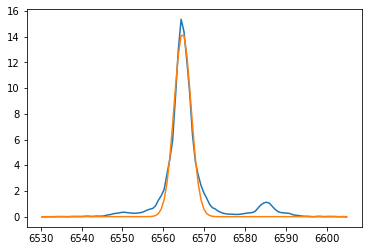

In [5]:
ha_mask = (wl > 6530) & (wl < 6605)
wl_ha = wl[ha_mask]
flux_ha = flux[ha_mask]
noise_ha = noise[ha_mask]

pp_ha, pcov_ha = curve_fit(gaussian2, wl_ha, flux_ha,
                           p0=[64, 6564.5, 1.6],
                           sigma=noise_ha)
plt.plot(wl_ha, flux_ha)
plt.plot(wl_ha, gaussian2(wl_ha, *pp_ha))
print(pp_ha[1])

5008.472793748049


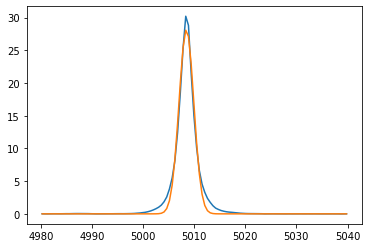

In [6]:
oiii5007_mask = (wl > 4980) & (wl < 5040)
wl_oiii5007 = wl[oiii5007_mask]
flux_oiii5007 = flux[oiii5007_mask]
noise_oiii5007 = noise[oiii5007_mask]

pp_oiii5007, pcov_oiii5007 = curve_fit(gaussian2, wl_oiii5007, flux_oiii5007,
                           p0=[90, 5008.5, 1.2],
                           sigma=noise_oiii5007)
plt.plot(wl_oiii5007, flux_oiii5007)
plt.plot(wl_oiii5007, gaussian2(wl_oiii5007, *pp_oiii5007))
print(pp_oiii5007[1])

<ErrorbarContainer object of 3 artists>

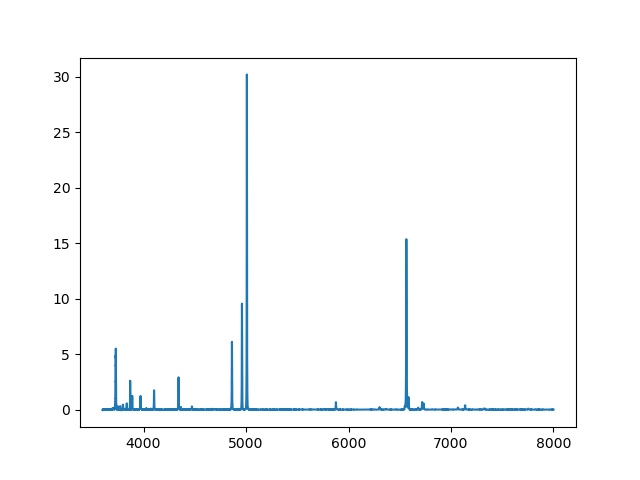

In [7]:
%matplotlib widget
plt.errorbar(wl, flux, noise)

In [8]:
hb_mask = (wl > 4840) & (wl < 4890)
wl_hb = wl[hb_mask]
flux_hb = flux[hb_mask]
noise_hb = noise[hb_mask]

pp_hb, pcov_hb = curve_fit(gaussian2, wl_hb, flux_hb,
                           p0=[20, 4862.5, 1.3],
                           sigma=noise_hb)
plt.plot(wl_hb, flux_hb)
plt.plot(wl_hb, gaussian2(wl_hb, *pp_hb))
print(pp_hb[1])

4862.673853806485


In [9]:
hg_mask = (wl > 4320) & (wl < 4360)
wl_hg = wl[hg_mask]
flux_hg = flux[hg_mask]
noise_hg = noise[hg_mask]

pp_hg, pcov_hg = curve_fit(gaussian2, wl_hg, flux_hg,
                           p0=[10, 4342, 1.3],
                           sigma=noise_hg)
plt.plot(wl_hg, flux_hg)
plt.plot(wl_hg, gaussian2(wl_hg, *pp_hg))
print(pp_hg[1])

4341.72438829988


In [10]:
oi6300_mask = (wl > 6280) & (wl < 6310)
wl_oi6300 = wl[oi6300_mask]
flux_oi6300 = flux[oi6300_mask]
noise_oi6300 = noise[oi6300_mask]

pp_oi6300, pcov_oi6300 = curve_fit(gaussian2, wl_oi6300, flux_oi6300,
                           p0=[1, 6302.5, 1.8],
                           sigma=noise_oi6300)
plt.plot(wl_oi6300, flux_oi6300)
plt.plot(wl_oi6300, gaussian2(wl_oi6300, *pp_oi6300))
print(pp_oi6300[1])

6302.457795826676


In [11]:
sii6716_mask = (wl > 6695) & (wl < 6725.5)
sii6730_mask = (wl > 6725.5) & (wl < 6760)
wl_sii6716 = wl[sii6716_mask]
wl_sii6730 = wl[sii6730_mask]
flux_sii6716 = flux[sii6716_mask]
flux_sii6730 = flux[sii6730_mask]
noise_sii6716 = noise[sii6716_mask]
noise_sii6730 = noise[sii6730_mask]

In [12]:
pp_sii6716, pcov_sii6716 = curve_fit(gaussian2, wl_sii6716, flux_sii6716,
                           p0=[3.5, 6718.5, 2.0],
                           sigma=noise_sii6716)
plt.plot(wl_sii6716, flux_sii6716)
plt.plot(wl_sii6716, gaussian2(wl_sii6716, *pp_sii6716))
print(pp_sii6716[1])

6718.598013161514


In [13]:
pp_sii6730, pcov_sii6730 = curve_fit(gaussian2, wl_sii6730, flux_sii6730,
                           p0=[2.7, 6733, 2.0],
                           sigma=noise_sii6730)
plt.plot(wl_sii6730, flux_sii6730)
plt.plot(wl_sii6730, gaussian2(wl_sii6730, *pp_sii6730))
print(pp_sii6730[1])

6732.800220240183


In [14]:
nii6548_mask = (wl > 6520) & (wl < 6552.7)
nii6584_mask = (wl > 6577.4) & (wl < 6620)
wl_nii6548 = wl[nii6548_mask]
wl_nii6584 = wl[nii6584_mask]
flux_nii6548 = flux[nii6548_mask]
flux_nii6584 = flux[nii6584_mask]
noise_nii6548 = noise[nii6548_mask]
noise_nii6584 = noise[nii6584_mask]

In [15]:
pp_nii6548, pcov_nii6548 = curve_fit(gaussian2, wl_nii6548, flux_nii6548,
                           p0=[2.5, 6550.5, 3.0],
                           sigma=noise_nii6548)
plt.plot(wl_nii6548, flux_nii6548)
plt.plot(wl_nii6548, gaussian2(wl_nii6548, *pp_nii6548))
print(pp_nii6548[1])

6550.473049443602


In [16]:
pp_nii6584, pcov_nii6584 = curve_fit(gaussian2, wl_nii6584, flux_nii6584,
                           p0=[6, 6585, 2.0],
                           sigma=noise_nii6584)
plt.plot(wl_nii6584, flux_nii6584)
plt.plot(wl_nii6584, gaussian2(wl_nii6584, *pp_nii6584))
print(pp_nii6584[1])
# can be 6584.7

6585.342438789213


In [17]:
oii3726_mask = (wl > 3716) & (wl < 3728.5)
wl_oii3726 = wl[oii3726_mask]
flux_oii3726 = flux[oii3726_mask]
noise_oii3726 = noise[oii3726_mask]

pp_oii3726, pcov_oii3726 = curve_fit(gaussian2, wl_oii3726, flux_oii3726,
                           p0=[18, 3727.5, 1.5],
                           sigma=noise_oii3726)
plt.plot(wl_oii3726, flux_oii3726)
plt.plot(wl_oii3726, gaussian2(wl_oii3726, *pp_oii3726))
print(pp_oii3726[1])

3727.840861914801


In [18]:
#c = 299792.458 # km/s
#v_ha = ((wl_ha - 6562.801) / 6562.801) * c
#v_hb = ((wl_hb - 4861.363) / 4861.363) * c
#v_hg = ((wl_hg - air(4341.68)) / air(4341.68)) * c
#v_oi6300 = ((wl_oi6300 - air(6302.046)) / air(6302.046)) * c
#v_sii6716 = ((wl_sii6716 - 6716.44) / 6716.44) * c
#v_sii6730 = ((wl_sii6730 - 6730.82) / 6730.82) * c
#v_oii3726 = ((wl_oii3726 - air(3727.092)) / air(3727.092)) * c
#v_nii6548 = ((wl_nii6548 - 6548.05) / 6548.05) * c
#v_nii6584 = ((wl_nii6584 - 6583.45) / 6583.45) * c

c = 299792.458 # km/s
v_ha = ((wl_ha - pp_ha[1]) / pp_ha[1]) * c
v_hb = ((wl_hb - pp_hb[1]) / pp_hb[1]) * c
v_hg = ((wl_hg - pp_hg[1]) / pp_hg[1]) * c
v_oi6300 = ((wl_oi6300 - pp_oi6300[1]) / pp_oi6300[1]) * c
v_sii6716 = ((wl_sii6716 - pp_sii6716[1]) / pp_sii6716[1]) * c
v_sii6730 = ((wl_sii6730 - pp_sii6730[1]) / pp_sii6730[1]) * c
v_oii3726 = ((wl_oii3726 - pp_oii3726[1]) / pp_oii3726[1]) * c
v_nii6548 = ((wl_nii6548 - pp_nii6548[1]) / pp_nii6548[1]) * c
v_nii6584 = ((wl_nii6584 - pp_nii6584[1]) / pp_nii6584[1]) * c

Text(0.5, 0, '$v$ [km/s]')

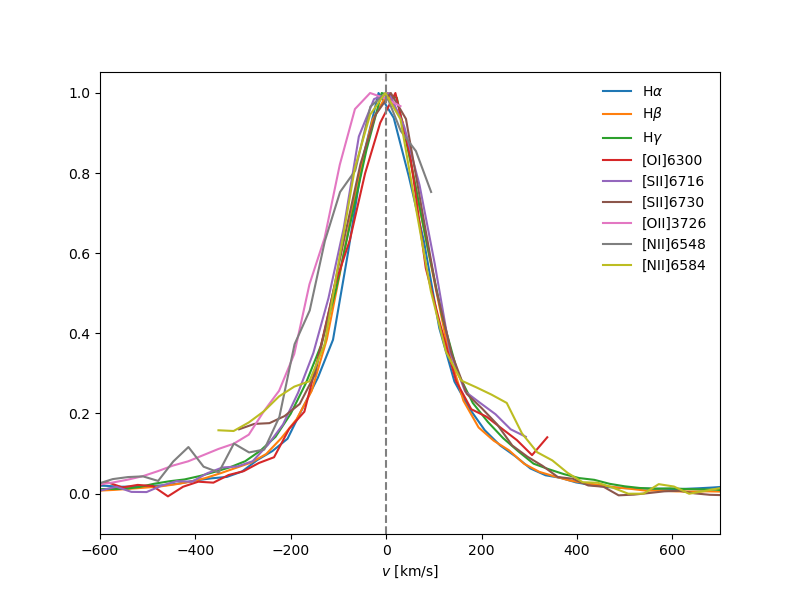

In [19]:
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
plt.plot(v_ha, flux_ha/max(flux_ha), label=r'H$\alpha$')
plt.plot(v_hb, flux_hb/max(flux_hb), label=r'H$\beta$')
plt.plot(v_hg, flux_hg/max(flux_hg), label=r'H$\gamma$')
plt.plot(v_oi6300, flux_oi6300/max(flux_oi6300), label='[OI]6300')
plt.plot(v_sii6716, flux_sii6716/max(flux_sii6716), label='[SII]6716')
plt.plot(v_sii6730, flux_sii6730/max(flux_sii6730), label='[SII]6730')
plt.plot(v_oii3726, flux_oii3726/max(flux_oii3726), label='[OII]3726')
plt.plot(v_nii6548, flux_nii6548/max(flux_nii6548), label='[NII]6548')
plt.plot(v_nii6584, flux_nii6584/max(flux_nii6584), label='[NII]6584')
plt.axvline(0, ls='--', color='gray')
plt.xlim(-600, 700)
plt.legend(frameon=False)
plt.xlabel(r'$v$ [km/s]')
#plt.savefig('vlow.png', bbox_inches='tight', transparent=False, facecolor='white')

In [20]:
oiii4959_mask = (wl > 4930) & (wl < 4990)
wl_oiii4959 = wl[oiii4959_mask]
flux_oiii4959 = flux[oiii4959_mask]
noise_oiii4959 = noise[oiii4959_mask]

pp_oiii4959, pcov_oiii4959 = curve_fit(gaussian2, wl_oiii4959, flux_oiii4959,
                           p0=[36, 4960.5, 1.5],
                           sigma=noise_oiii4959)
plt.plot(wl_oiii4959, flux_oiii4959)
plt.plot(wl_oiii4959, gaussian2(wl_oiii4959, *pp_oiii4959))
print(pp_oiii4959[1])

4960.458444919012


In [21]:
oiii4363_mask = (wl > 4353) & (wl < 4382)
wl_oiii4363 = wl[oiii4363_mask]
flux_oiii4363 = flux[oiii4363_mask]
noise_oiii4363 = noise[oiii4363_mask]

pp_oiii4363, pcov_oiii4363 = curve_fit(gaussian2, wl_oiii4363, flux_oiii4363,
                           p0=[0.9, 4364.5, 1.5],
                           sigma=noise_oiii4363)
plt.plot(wl_oiii4363, flux_oiii4363)
plt.plot(wl_oiii4363, gaussian2(wl_oiii4363, *pp_oiii4363))
print(pp_oiii4363[1])

4364.212936654878


In [22]:
neiii3968_mask = (wl > 3955) & (wl < 3969.8)
wl_neiii3968 = wl[neiii3968_mask]
flux_neiii3968 = flux[neiii3968_mask]
noise_neiii3968 = noise[neiii3968_mask]

pp_neiii3968, pcov_neiii3968 = curve_fit(gaussian2, wl_neiii3968, flux_neiii3968,
                           p0=[4, 3969, 1.5],
                           sigma=noise_neiii3968)
plt.plot(wl_neiii3968, flux_neiii3968)
plt.plot(wl_neiii3968, gaussian2(wl_neiii3968, *pp_neiii3968))
print(pp_neiii3968[1])

3969.800588383806


In [23]:
neiii3869_mask = (wl > 3850) & (wl < 3880)
wl_neiii3869 = wl[neiii3869_mask]
flux_neiii3869 = flux[neiii3869_mask]
noise_neiii3869 = noise[neiii3869_mask]

pp_neiii3869, pcov_neiii3869 = curve_fit(gaussian2, wl_neiii3869, flux_neiii3869,
                           p0=[6.5, 3869.8, 1.0],
                           sigma=noise_neiii3869)
plt.plot(wl_neiii3869, flux_neiii3869)
plt.plot(wl_neiii3869, gaussian2(wl_neiii3869, *pp_neiii3869))
print(pp_neiii3869[1])

3869.798172726442


In [24]:
#v_oiii5007 = ((wl_oiii5007 - 5006.843) / 5006.843) * c
#v_oiii4959 = ((wl_oiii4959 - 4958.911) / 4958.911) * c
#v_oiii4363 = ((wl_oiii4363 - air(4364.436)) / air(4364.436)) * c
#v_neiii3968 = ((wl_neiii3968 - 3967.47) / 3967.47) * c
#v_neiii3869 = ((wl_neiii3869 - 3868.76) / 3868.76) * c

c = 299792.458 # km/s
v_oiii5007 = ((wl_oiii5007 - pp_oiii5007[1]) / pp_oiii5007[1]) * c
v_oiii4959 = ((wl_oiii4959 - pp_oiii4959[1]) / pp_oiii4959[1]) * c
v_oiii4363 = ((wl_oiii4363 - pp_oiii4363[1]) / pp_oiii4363[1]) * c
v_neiii3968 = ((wl_neiii3968 - pp_neiii3968[1]) / pp_neiii3968[1]) * c
v_neiii3869 = ((wl_neiii3869 - pp_neiii3869[1]) / pp_neiii3869[1]) * c

Text(0.5, 0, '$v$ [km/s]')

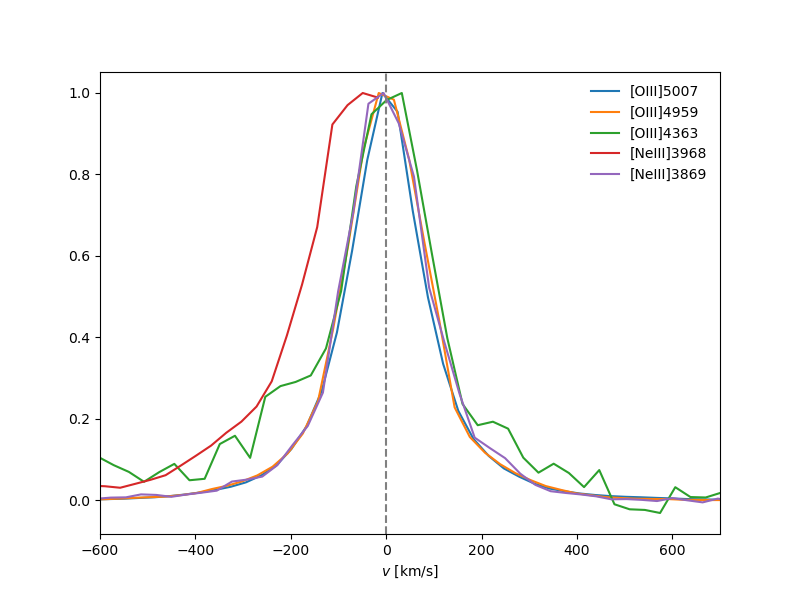

In [25]:
%matplotlib widget
plt.figure(figsize=(8, 6))
plt.plot(v_oiii5007, flux_oiii5007/max(flux_oiii5007), label=r'[OIII]5007')
plt.plot(v_oiii4959, flux_oiii4959/max(flux_oiii4959), label=r'[OIII]4959')
plt.plot(v_oiii4363, flux_oiii4363/max(flux_oiii4363), label=r'[OIII]4363')
plt.plot(v_neiii3968, flux_neiii3968/max(flux_neiii3968), label=r'[NeIII]3968')
plt.plot(v_neiii3869, flux_neiii3869/max(flux_neiii3869), label=r'[NeIII]3869')
plt.axvline(0, ls='--', color='gray')
plt.xlim(-600, 700)
plt.legend(frameon=False)
plt.xlabel(r'$v$ [km/s]')
#plt.savefig('vhigh.png', bbox_inches='tight', transparent=False, facecolor='white')

In [26]:
vel = np.arange(-600, 600, 20)
high = np.zeros(len(vel))
for i in range(len(vel)):
    bot = vel[i]-10
    top = vel[i]+10
    a = np.nanmean(flux_oiii5007[(v_oiii5007 > bot) & (v_oiii5007 < top)]/max(flux_oiii5007))
    b = np.nanmean(flux_oiii4959[(v_oiii4959 > bot) & (v_oiii4959 < top)]/max(flux_oiii4959))
    c = np.nanmean(flux_oiii4363[(v_oiii4363 > bot) & (v_oiii4363 < top)]/max(flux_oiii4363))
    d = np.nanmean(flux_neiii3968[(v_neiii3968 > bot) & (v_neiii3968 < top)]/max(flux_neiii3968))
    e = np.nanmean(flux_neiii3869[(v_neiii3869 > bot) & (v_neiii3869 < top)]/max(flux_neiii3869))
    high[i] = np.nanmean([a, b, c, d, e])

/tmp/ipykernel_858083/3970770629.py:6: RuntimeWarning: Mean of empty slice
  a = np.nanmean(flux_oiii5007[(v_oiii5007 > bot) & (v_oiii5007 < top)]/max(flux_oiii5007))
/tmp/ipykernel_858083/3970770629.py:7: RuntimeWarning: Mean of empty slice
  b = np.nanmean(flux_oiii4959[(v_oiii4959 > bot) & (v_oiii4959 < top)]/max(flux_oiii4959))
/tmp/ipykernel_858083/3970770629.py:9: RuntimeWarning: Mean of empty slice
  d = np.nanmean(flux_neiii3968[(v_neiii3968 > bot) & (v_neiii3968 < top)]/max(flux_neiii3968))
/tmp/ipykernel_858083/3970770629.py:8: RuntimeWarning: Mean of empty slice
  c = np.nanmean(flux_oiii4363[(v_oiii4363 > bot) & (v_oiii4363 < top)]/max(flux_oiii4363))
/tmp/ipykernel_858083/3970770629.py:10: RuntimeWarning: Mean of empty slice
  e = np.nanmean(flux_neiii3869[(v_neiii3869 > bot) & (v_neiii3869 < top)]/max(flux_neiii3869))


In [27]:
low = np.zeros(len(vel))
for i in range(len(vel)):
    bot = vel[i]-10
    top = vel[i]+10
    a = np.nanmean(flux_ha[(v_ha > bot) & (v_ha < top)]/max(flux_ha))
    b = np.nanmean(flux_hb[(v_hb > bot) & (v_hb < top)]/max(flux_hb))
    c = np.nanmean(flux_hg[(v_hg > bot) & (v_hg < top)]/max(flux_hg))
    d = np.nanmean(flux_oi6300[(v_oi6300 > bot) & (v_oi6300 < top)]/max(flux_oi6300))
    e = np.nanmean(flux_sii6716[(v_sii6716 > bot) & (v_sii6716 < top)]/max(flux_sii6716))
    f = np.nanmean(flux_sii6730[(v_sii6730 > bot) & (v_sii6730 < top)]/max(flux_sii6730))
    g = np.nanmean(flux_nii6548[(v_nii6548 > bot) & (v_nii6548 < top)]/max(flux_nii6548))
    h = np.nanmean(flux_nii6584[(v_nii6584 > bot) & (v_nii6584 < top)]/max(flux_nii6584))
    j = np.nanmean(flux_oii3726[(v_oii3726 > bot) & (v_oii3726 < top)]/max(flux_oii3726))
    low[i] = np.nanmean([a, b, c, d, e, f, g, h, j])

/tmp/ipykernel_858083/3666434269.py:5: RuntimeWarning: Mean of empty slice
  a = np.nanmean(flux_ha[(v_ha > bot) & (v_ha < top)]/max(flux_ha))
/tmp/ipykernel_858083/3666434269.py:7: RuntimeWarning: Mean of empty slice
  c = np.nanmean(flux_hg[(v_hg > bot) & (v_hg < top)]/max(flux_hg))
/tmp/ipykernel_858083/3666434269.py:8: RuntimeWarning: Mean of empty slice
  d = np.nanmean(flux_oi6300[(v_oi6300 > bot) & (v_oi6300 < top)]/max(flux_oi6300))
/tmp/ipykernel_858083/3666434269.py:10: RuntimeWarning: Mean of empty slice
  f = np.nanmean(flux_sii6730[(v_sii6730 > bot) & (v_sii6730 < top)]/max(flux_sii6730))
/tmp/ipykernel_858083/3666434269.py:12: RuntimeWarning: Mean of empty slice
  h = np.nanmean(flux_nii6584[(v_nii6584 > bot) & (v_nii6584 < top)]/max(flux_nii6584))
/tmp/ipykernel_858083/3666434269.py:6: RuntimeWarning: Mean of empty slice
  b = np.nanmean(flux_hb[(v_hb > bot) & (v_hb < top)]/max(flux_hb))
/tmp/ipykernel_858083/3666434269.py:9: RuntimeWarning: Mean of empty slice
  e = np.

Text(0.5, 0, '$v$ [km/s]')

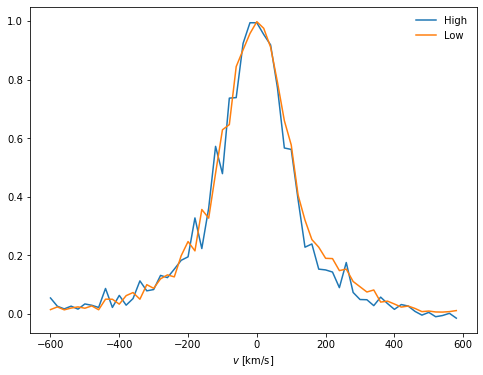

In [28]:
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.plot(vel, high, label='High')
plt.plot(vel, low, label='Low')
plt.legend(frameon=False)
plt.xlabel(r'$v$ [km/s]')
#plt.savefig('mean.png', bbox_inches='tight', facecolor='white')

In [29]:
vel = np.arange(-600, 600, 20)
high = np.zeros(len(vel))
for i in range(len(vel)):
    bot = vel[i]-10
    top = vel[i]+10
    a = np.nanmean(flux_oiii5007[(v_oiii5007 > bot) & (v_oiii5007 < top)]/max(flux_oiii5007))
    b = np.nanmean(flux_oiii4959[(v_oiii4959 > bot) & (v_oiii4959 < top)]/max(flux_oiii4959))
    c = np.nanmean(flux_oiii4363[(v_oiii4363 > bot) & (v_oiii4363 < top)]/max(flux_oiii4363))
    e = np.nanmean(flux_neiii3869[(v_neiii3869 > bot) & (v_neiii3869 < top)]/max(flux_neiii3869))
    high[i] = np.nanmean([a, b, c, e])

/tmp/ipykernel_858083/1877417930.py:6: RuntimeWarning: Mean of empty slice
  a = np.nanmean(flux_oiii5007[(v_oiii5007 > bot) & (v_oiii5007 < top)]/max(flux_oiii5007))
/tmp/ipykernel_858083/1877417930.py:7: RuntimeWarning: Mean of empty slice
  b = np.nanmean(flux_oiii4959[(v_oiii4959 > bot) & (v_oiii4959 < top)]/max(flux_oiii4959))
/tmp/ipykernel_858083/1877417930.py:8: RuntimeWarning: Mean of empty slice
  c = np.nanmean(flux_oiii4363[(v_oiii4363 > bot) & (v_oiii4363 < top)]/max(flux_oiii4363))
/tmp/ipykernel_858083/1877417930.py:9: RuntimeWarning: Mean of empty slice
  e = np.nanmean(flux_neiii3869[(v_neiii3869 > bot) & (v_neiii3869 < top)]/max(flux_neiii3869))


In [30]:
low = np.zeros(len(vel))
for i in range(len(vel)):
    bot = vel[i]-10
    top = vel[i]+10
    a = np.nanmean(flux_ha[(v_ha > bot) & (v_ha < top)]/max(flux_ha))
    b = np.nanmean(flux_hb[(v_hb > bot) & (v_hb < top)]/max(flux_hb))
    c = np.nanmean(flux_hg[(v_hg > bot) & (v_hg < top)]/max(flux_hg))
    d = np.nanmean(flux_oi6300[(v_oi6300 > bot) & (v_oi6300 < top)]/max(flux_oi6300))
    e = np.nanmean(flux_sii6716[(v_sii6716 > bot) & (v_sii6716 < top)]/max(flux_sii6716))
    f = np.nanmean(flux_sii6730[(v_sii6730 > bot) & (v_sii6730 < top)]/max(flux_sii6730))
    low[i] = np.nanmean([a, b, c, d, e, f])

/tmp/ipykernel_858083/3746650354.py:5: RuntimeWarning: Mean of empty slice
  a = np.nanmean(flux_ha[(v_ha > bot) & (v_ha < top)]/max(flux_ha))
/tmp/ipykernel_858083/3746650354.py:7: RuntimeWarning: Mean of empty slice
  c = np.nanmean(flux_hg[(v_hg > bot) & (v_hg < top)]/max(flux_hg))
/tmp/ipykernel_858083/3746650354.py:8: RuntimeWarning: Mean of empty slice
  d = np.nanmean(flux_oi6300[(v_oi6300 > bot) & (v_oi6300 < top)]/max(flux_oi6300))
/tmp/ipykernel_858083/3746650354.py:10: RuntimeWarning: Mean of empty slice
  f = np.nanmean(flux_sii6730[(v_sii6730 > bot) & (v_sii6730 < top)]/max(flux_sii6730))
/tmp/ipykernel_858083/3746650354.py:6: RuntimeWarning: Mean of empty slice
  b = np.nanmean(flux_hb[(v_hb > bot) & (v_hb < top)]/max(flux_hb))
/tmp/ipykernel_858083/3746650354.py:9: RuntimeWarning: Mean of empty slice
  e = np.nanmean(flux_sii6716[(v_sii6716 > bot) & (v_sii6716 < top)]/max(flux_sii6716))


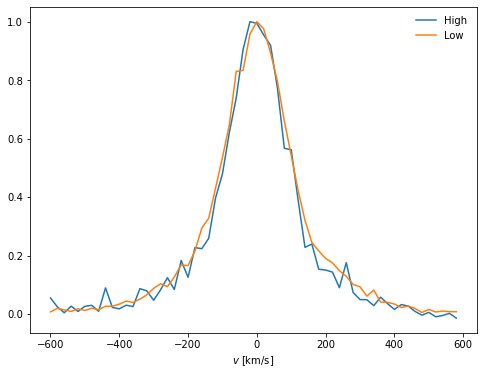

In [32]:
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.plot(vel, high, label='High')
plt.plot(vel, low, label='Low')
plt.legend(frameon=False)
plt.xlabel(r'$v$ [km/s]')
#plt.savefig('mean_no_SN.png', bbox_inches='tight', facecolor='white')

# 2 gaussians

## [NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584

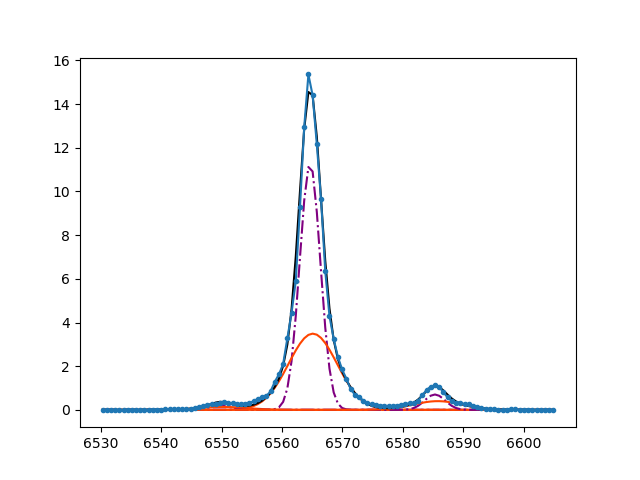

In [21]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 48, ha_wav, z=2.8e-04, sigma=1.7)
ha_brd = gaussian(wl_ha, 35, ha_wav, z=3.5e-04, sigma=4.0)

niib_nar = gaussian(wl_ha, 3/3, niib_wav, z=2.8e-04, sigma=1.7)
niib_brd = gaussian(wl_ha, 4/3, niib_wav, z=3.5e-04, sigma=4.0)

niia_nar = gaussian(wl_ha, 3, niia_wav, z=2.8e-04, sigma=1.7)
niia_brd = gaussian(wl_ha, 4, niia_wav, z=3.5e-04, sigma=4.0)

# total
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='-.')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='-.')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='-.')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [22]:
params2_ha_nii = Parameters()

params2_ha_nii.add('z_nar', value=2.8e-04)
params2_ha_nii.add('z_brd', value=3.5e-04)
params2_ha_nii.add('sigma_nar', value=1.7, min=0.)
params2_ha_nii.add('sigma_brd', value=4.0, min=0.)
params2_ha_nii.add('Ha_nar', value=48, min=0.)
params2_ha_nii.add('Ha_brd', value=35, min=0.)
params2_ha_nii.add('Niia_nar', value=3, min=0.)
params2_ha_nii.add('Niia_brd', value=4, min=0.)
params2_ha_nii.add('Niib_to_niia', value=1/3, vary=False)


def residual2_ha_nii(params2_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params2_ha_nii['z_nar']
    z_brd = params2_ha_nii['z_brd']
    sigma_nar = params2_ha_nii['sigma_nar']
    sigma_brd = params2_ha_nii['sigma_brd']
    ha_nar = params2_ha_nii['Ha_nar']
    ha_brd = params2_ha_nii['Ha_brd']
    niia_nar = params2_ha_nii['Niia_nar']
    niia_brd = params2_ha_nii['Niia_brd']
    niib_nar = params2_ha_nii['Niia_nar']*params2_ha_nii['Niib_to_niia']
    niib_brd = params2_ha_nii['Niia_brd']*params2_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd)
    
    model = model_niib + model_ha + model_niia
    
    return (model - flux_ha) / noise_ha

In [23]:
n_params2_ha_nii = 8
out2_ha_nii = minimize(residual2_ha_nii, params2_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, nwalkers=n_params2_ha_nii*9, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:31<00:00, 96.09it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [ 25.47158729  25.9885679  154.55038293 176.43826147 172.95655528
 167.51347159 170.57766694 167.76790746]


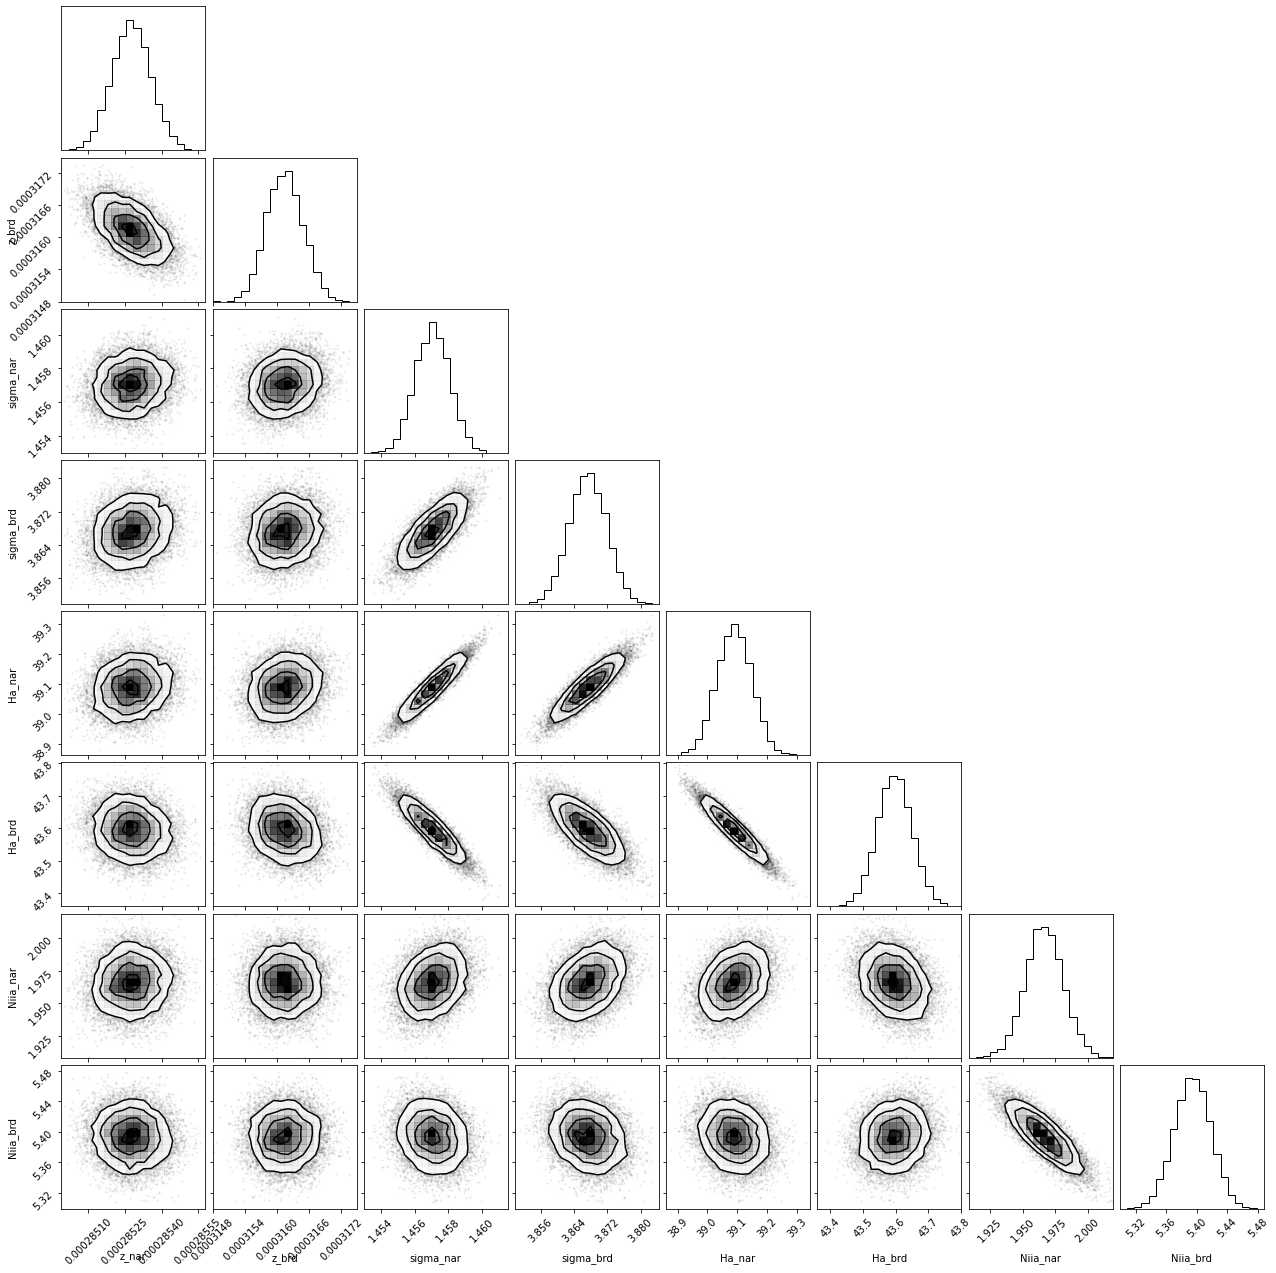

In [24]:
%matplotlib inline
corner.corner(out2_ha_nii.flatchain, labels=out2_ha_nii.var_names);

In [25]:
out2_ha_nii

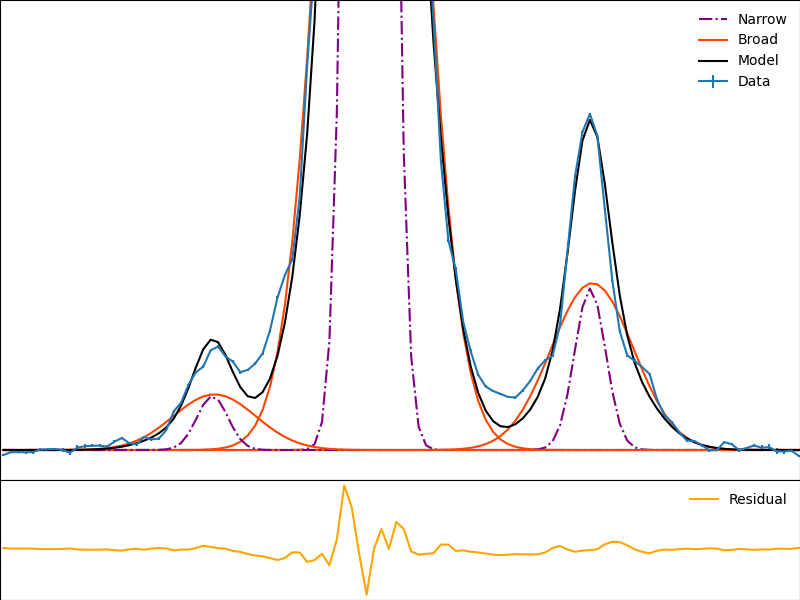

In [33]:
ha2_nar = out2_ha_nii.flatchain.Ha_nar.mean()
ha2_brd = out2_ha_nii.flatchain.Ha_brd.mean()

niia2_nar = out2_ha_nii.flatchain.Niia_nar.mean()
niia2_brd = out2_ha_nii.flatchain.Niia_brd.mean()

niib2_nar = (out2_ha_nii.flatchain.Niia_nar/3).mean()
niib2_brd = (out2_ha_nii.flatchain.Niia_brd/3).mean()

z2_ha_nar = out2_ha_nii.flatchain.z_nar.mean()
z2_ha_brd = out2_ha_nii.flatchain.z_brd.mean()

sigma2_ha_nar = out2_ha_nii.flatchain.sigma_nar.mean()
sigma2_ha_brd = out2_ha_nii.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='Data')

ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib2_nar = gaussian(wl_ha, niib2_nar, niib_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
niib2_brd = gaussian(wl_ha, niib2_brd, niib_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

ha2_nar = gaussian(wl_ha, ha2_nar, ha_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
ha2_brd = gaussian(wl_ha, ha2_brd, ha_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

niia2_nar = gaussian(wl_ha, niia2_nar, niia_wav, z=z2_ha_nar, sigma=sigma2_ha_nar)
niia2_brd = gaussian(wl_ha, niia2_brd, niia_wav, z=z2_ha_brd, sigma=sigma2_ha_brd)

ha2 = ha_nar + ha_brd
niia2 = niia_nar + niia_brd
niib2 = niib_nar + niib_brd

ax.plot(wl_ha, ha2_nar, color='purple', ls='-.', label='Narrow')
ax.plot(wl_ha, ha2_brd, color='orangered', label='Broad')
ax.plot(wl_ha, niia2_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia2_brd, color='orangered')
ax.plot(wl_ha, niib2_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib2_brd, color='orangered')
ax.plot(wl_ha, niib2 + ha2 + niia2, color='black', label='Model')

ax1.plot(wl_ha, niib2 + ha2 + niia2 - flux_ha, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
ax.set_xlim(6530, 6605)
ax1.set_xlim(6530, 6605)
ax.set_xticks([])
ax.set_ylim(-0.1, 1.5)
#plt.savefig('2compfit_ha_zoom.png', bbox_inches='tight', facecolor='white')

## [OIII]$\lambda$5007

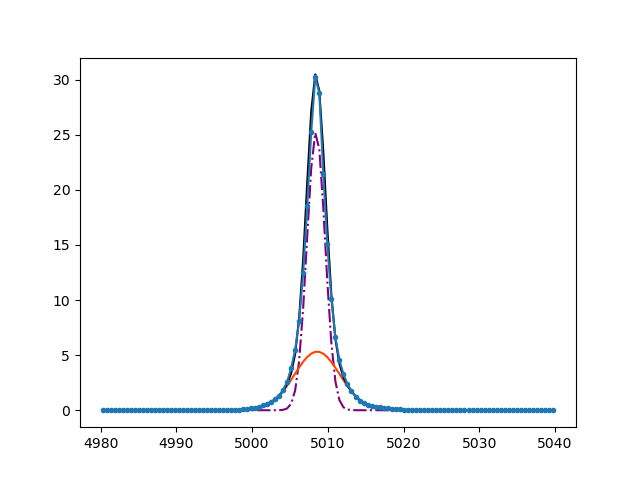

In [34]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_oiii5007, flux_oiii5007, noise_oiii5007,
             marker='o', markersize=3, label='data')

#air 
oiii5007_wav = 5006.843

# narrow and broad
oiii5007_nar = gaussian(wl_oiii5007, 76, oiii5007_wav, z=3.2e-04, sigma=1.2)
oiii5007_brd = gaussian(wl_oiii5007, 40, oiii5007_wav, z=3.5e-04, sigma=3.0)

oiii5007 = oiii5007_nar + oiii5007_brd

plt.plot(wl_oiii5007, oiii5007_nar, color='purple', ls='-.')
plt.plot(wl_oiii5007, oiii5007_brd, color='orangered')

plt.plot(wl_oiii5007, oiii5007, color='black')

In [35]:
params2_oiii5007 = Parameters()

params2_oiii5007.add('z_nar', value=3.2e-4)
params2_oiii5007.add('z_brd', value=3.5e-4)
params2_oiii5007.add('sigma_nar', value=1.2, min=0.)
params2_oiii5007.add('sigma_brd', value=3.0, min=0.)
params2_oiii5007.add('Oiii5007_nar', value=76, min=0.)
params2_oiii5007.add('Oiii5007_brd', value=40, min=0.)

def residual2_oiii5007(params2_oiii5007, x, data, uncertainty):
    oiii5007_wav = 5006.843
    
    z_nar = params2_oiii5007['z_nar']
    z_brd = params2_oiii5007['z_brd']
    sigma_nar = params2_oiii5007['sigma_nar']
    sigma_brd = params2_oiii5007['sigma_brd']
    oiii5007_nar = params2_oiii5007['Oiii5007_nar']
    oiii5007_brd = params2_oiii5007['Oiii5007_brd']
    
    x = wl_oiii5007
    
    model_oiii5007 = gaussian(x, oiii5007_nar, oiii5007_wav, z_nar, sigma_nar) \
                   + gaussian(x, oiii5007_brd, oiii5007_wav, z_brd, sigma_brd)
    
    return (model_oiii5007 - flux_oiii5007) / noise_oiii5007

In [36]:
n_params2_oiii5007 = 6
out2_oiii5007 = minimize(residual2_oiii5007, params2_oiii5007, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, nwalkers=n_params2_oiii5007*9, seed=1)

100%|██████████████████████████████████████| 3000/3000 [00:13<00:00, 230.72it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [ 37.90739545  34.81232287 236.95889629 245.56845966 243.18801574
 245.94121413]


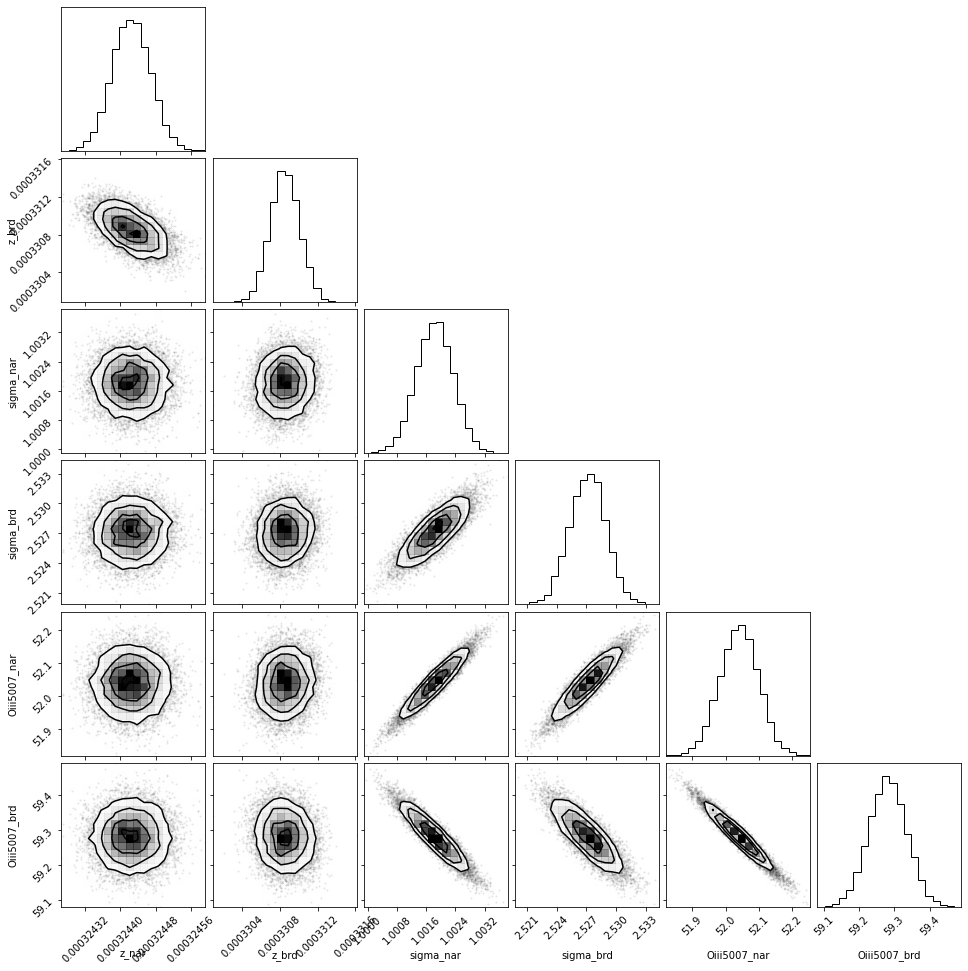

In [37]:
%matplotlib inline
corner.corner(out2_oiii5007.flatchain, labels=out2_oiii5007.var_names);

In [38]:
out2_oiii5007

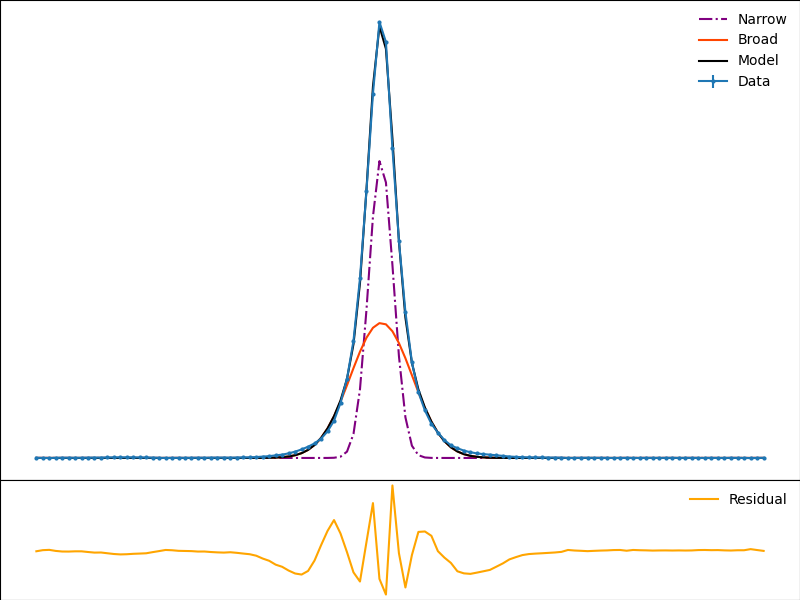

In [46]:
oiii5007_nar = out2_oiii5007.flatchain.Oiii5007_nar.mean()
oiii5007_brd = out2_oiii5007.flatchain.Oiii5007_brd.mean()

z_oiii5007_nar = out2_oiii5007.flatchain.z_nar.mean()
z_oiii5007_brd = out2_oiii5007.flatchain.z_brd.mean()

sigma_oiii5007_nar = out2_oiii5007.flatchain.sigma_nar.mean()
sigma_oiii5007_brd = out2_oiii5007.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

#data
ax.errorbar(wl_oiii5007, flux_oiii5007, noise_oiii5007, marker='.', markersize=4, label='Data')

# model
oiii5007_wav = 5006.843

oiii5007_nar = gaussian(wl_oiii5007, oiii5007_nar, oiii5007_wav, z=z_oiii5007_nar, sigma=sigma_oiii5007_nar)
oiii5007_brd = gaussian(wl_oiii5007, oiii5007_brd, oiii5007_wav, z=z_oiii5007_brd, sigma=sigma_oiii5007_brd)

oiii5007 = oiii5007_nar + oiii5007_brd

ax.plot(wl_oiii5007, oiii5007_nar, color='purple', ls='-.', label='Narrow')
ax.plot(wl_oiii5007, oiii5007_brd, color='orangered', label='Broad')
ax.plot(wl_oiii5007, oiii5007, color='black', label='Model')
                   
ax1.plot(wl_oiii5007, oiii5007 - flux_oiii5007, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
ax.set_xticks([])
#ax.set_xlim(4980, 5040)
#ax1.set_xlim(4980, 5040)
#ax.set_ylim(-0.1, 1.0)
#plt.savefig('2compfit_oiii.png', bbox_inches='tight', facecolor='white')

In [43]:
nu2_ha_nii = len(flux_ha) - n_params2_ha_nii
print('Reduced Xi2 for 2 gaussians for Ha '\
      + str(np.sum((niib + ha + niia - flux_ha)**2 / noise_ha) / nu2_ha_nii))

Reduced Xi2 for 2 gaussians for Ha 8.078663239257896


In [44]:
nu2_oiii5007 = len(flux_oiii5007) - n_params2_oiii5007
print('Reduced Xi2 for 2 gaussians for OIII '\
      + str(np.sum((oiii5007 - flux_oiii5007)**2 / noise_oiii5007) / nu2_oiii5007))

Reduced Xi2 for 2 gaussians for OIII 4.651065579644301


# 3 gaussians

## [NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584

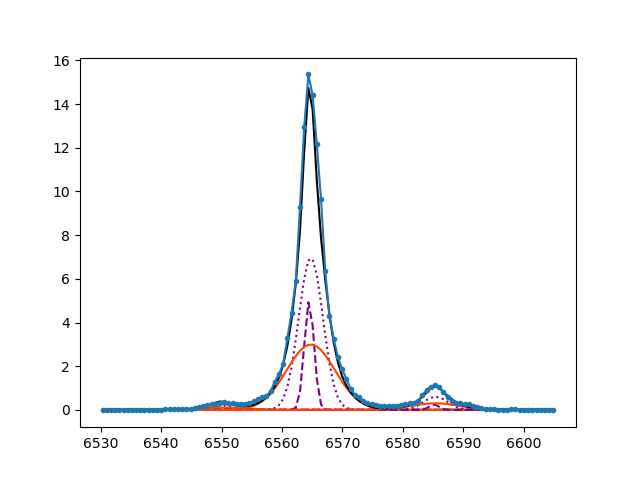

In [47]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 10, ha_wav, z=2.58e-04, sigma=0.8)
ha_mid = gaussian(wl_ha, 35, ha_wav, z=3.0e-04, sigma=2.0)
ha_brd = gaussian(wl_ha, 30, ha_wav, z=3.0e-04, sigma=4.0)

niib_nar = gaussian(wl_ha, 0.5/3, niib_wav, z=2.58e-04, sigma=0.8)
niib_mid = gaussian(wl_ha,   3/3, niib_wav, z=3.0e-04, sigma=2.)
niib_brd = gaussian(wl_ha,   3/3, niib_wav, z=3.0e-04, sigma=4.)

niia_nar = gaussian(wl_ha, 0.5, niia_wav, z=2.58e-04, sigma=0.8)
niia_mid = gaussian(wl_ha,   3, niia_wav, z=3.0e-04, sigma=2.)
niia_brd = gaussian(wl_ha,   3, niia_wav, z=3.0e-04, sigma=4.)

# total
ha = ha_nar + ha_mid + ha_brd
niib = niib_nar + niib_mid + niib_brd
niia = niia_nar + niia_mid + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='--')
plt.plot(wl_ha, ha_mid, color='purple', ls=':')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='--')
plt.plot(wl_ha, niib_mid, color='purple', ls=':')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='--')
plt.plot(wl_ha, niia_mid, color='purple', ls=':')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [48]:
params3_ha_nii = Parameters()

params3_ha_nii.add('z_nar', value=2.58e-04)
params3_ha_nii.add('z_mid', value=3.0e-04)
params3_ha_nii.add('z_brd', value=3.0e-04)

params3_ha_nii.add('sigma_nar', value=0.8, min=0.)
params3_ha_nii.add('sigma_mid', value=2.0, min=0.)
params3_ha_nii.add('sigma_brd', value=4.0, min=0.)

params3_ha_nii.add('Ha_nar', value=10, min=0.)
params3_ha_nii.add('Ha_mid', value=35, min=0.)
params3_ha_nii.add('Ha_brd', value=30, min=0.)

params3_ha_nii.add('Niia_nar', value=0.5, min=0.)
params3_ha_nii.add('Niia_mid', value=3, min=0.)
params3_ha_nii.add('Niia_brd', value=3, min=0.)

params3_ha_nii.add('Niib_to_niia', value=1/3, vary=False)

def residual3_ha_nii(params3_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params3_ha_nii['z_nar']
    z_mid = params3_ha_nii['z_mid']
    z_brd = params3_ha_nii['z_brd']
    
    sigma_nar = params3_ha_nii['sigma_nar']
    sigma_mid = params3_ha_nii['sigma_mid']
    sigma_brd = params3_ha_nii['sigma_brd']
    
    ha_nar = params3_ha_nii['Ha_nar']
    ha_mid = params3_ha_nii['Ha_mid']
    ha_brd = params3_ha_nii['Ha_brd']
    
    niia_nar = params3_ha_nii['Niia_nar']
    niia_mid = params3_ha_nii['Niia_mid']
    niia_brd = params3_ha_nii['Niia_brd']
    
    niib_nar = params3_ha_nii['Niia_nar']*params3_ha_nii['Niib_to_niia']
    niib_mid = params3_ha_nii['Niia_mid']*params3_ha_nii['Niib_to_niia']
    niib_brd = params3_ha_nii['Niia_brd']*params3_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd) \
             + gaussian(x, ha_mid, ha_wav, z_mid, sigma_mid)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd) \
               + gaussian(x, niia_mid, niia_wav, z_mid, sigma_mid)
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd) \
               + gaussian(x, niib_mid, niib_wav, z_mid, sigma_mid)
    
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [49]:
n_params3_ha_nii = 12
out3_ha_nii = minimize(residual3_ha_nii, params3_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=3000, thin=10,
                      workers=12, nwalkers=n_params3_ha_nii*9, seed=1)

100%|███████████████████████████████████████| 3000/3000 [01:03<00:00, 47.06it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [333.86613433 292.72284437 146.80833257 366.70516521 335.87675685
 270.03044313 356.2138609   89.46315101 314.75423048 377.15419412
 168.92643304 366.30446587]


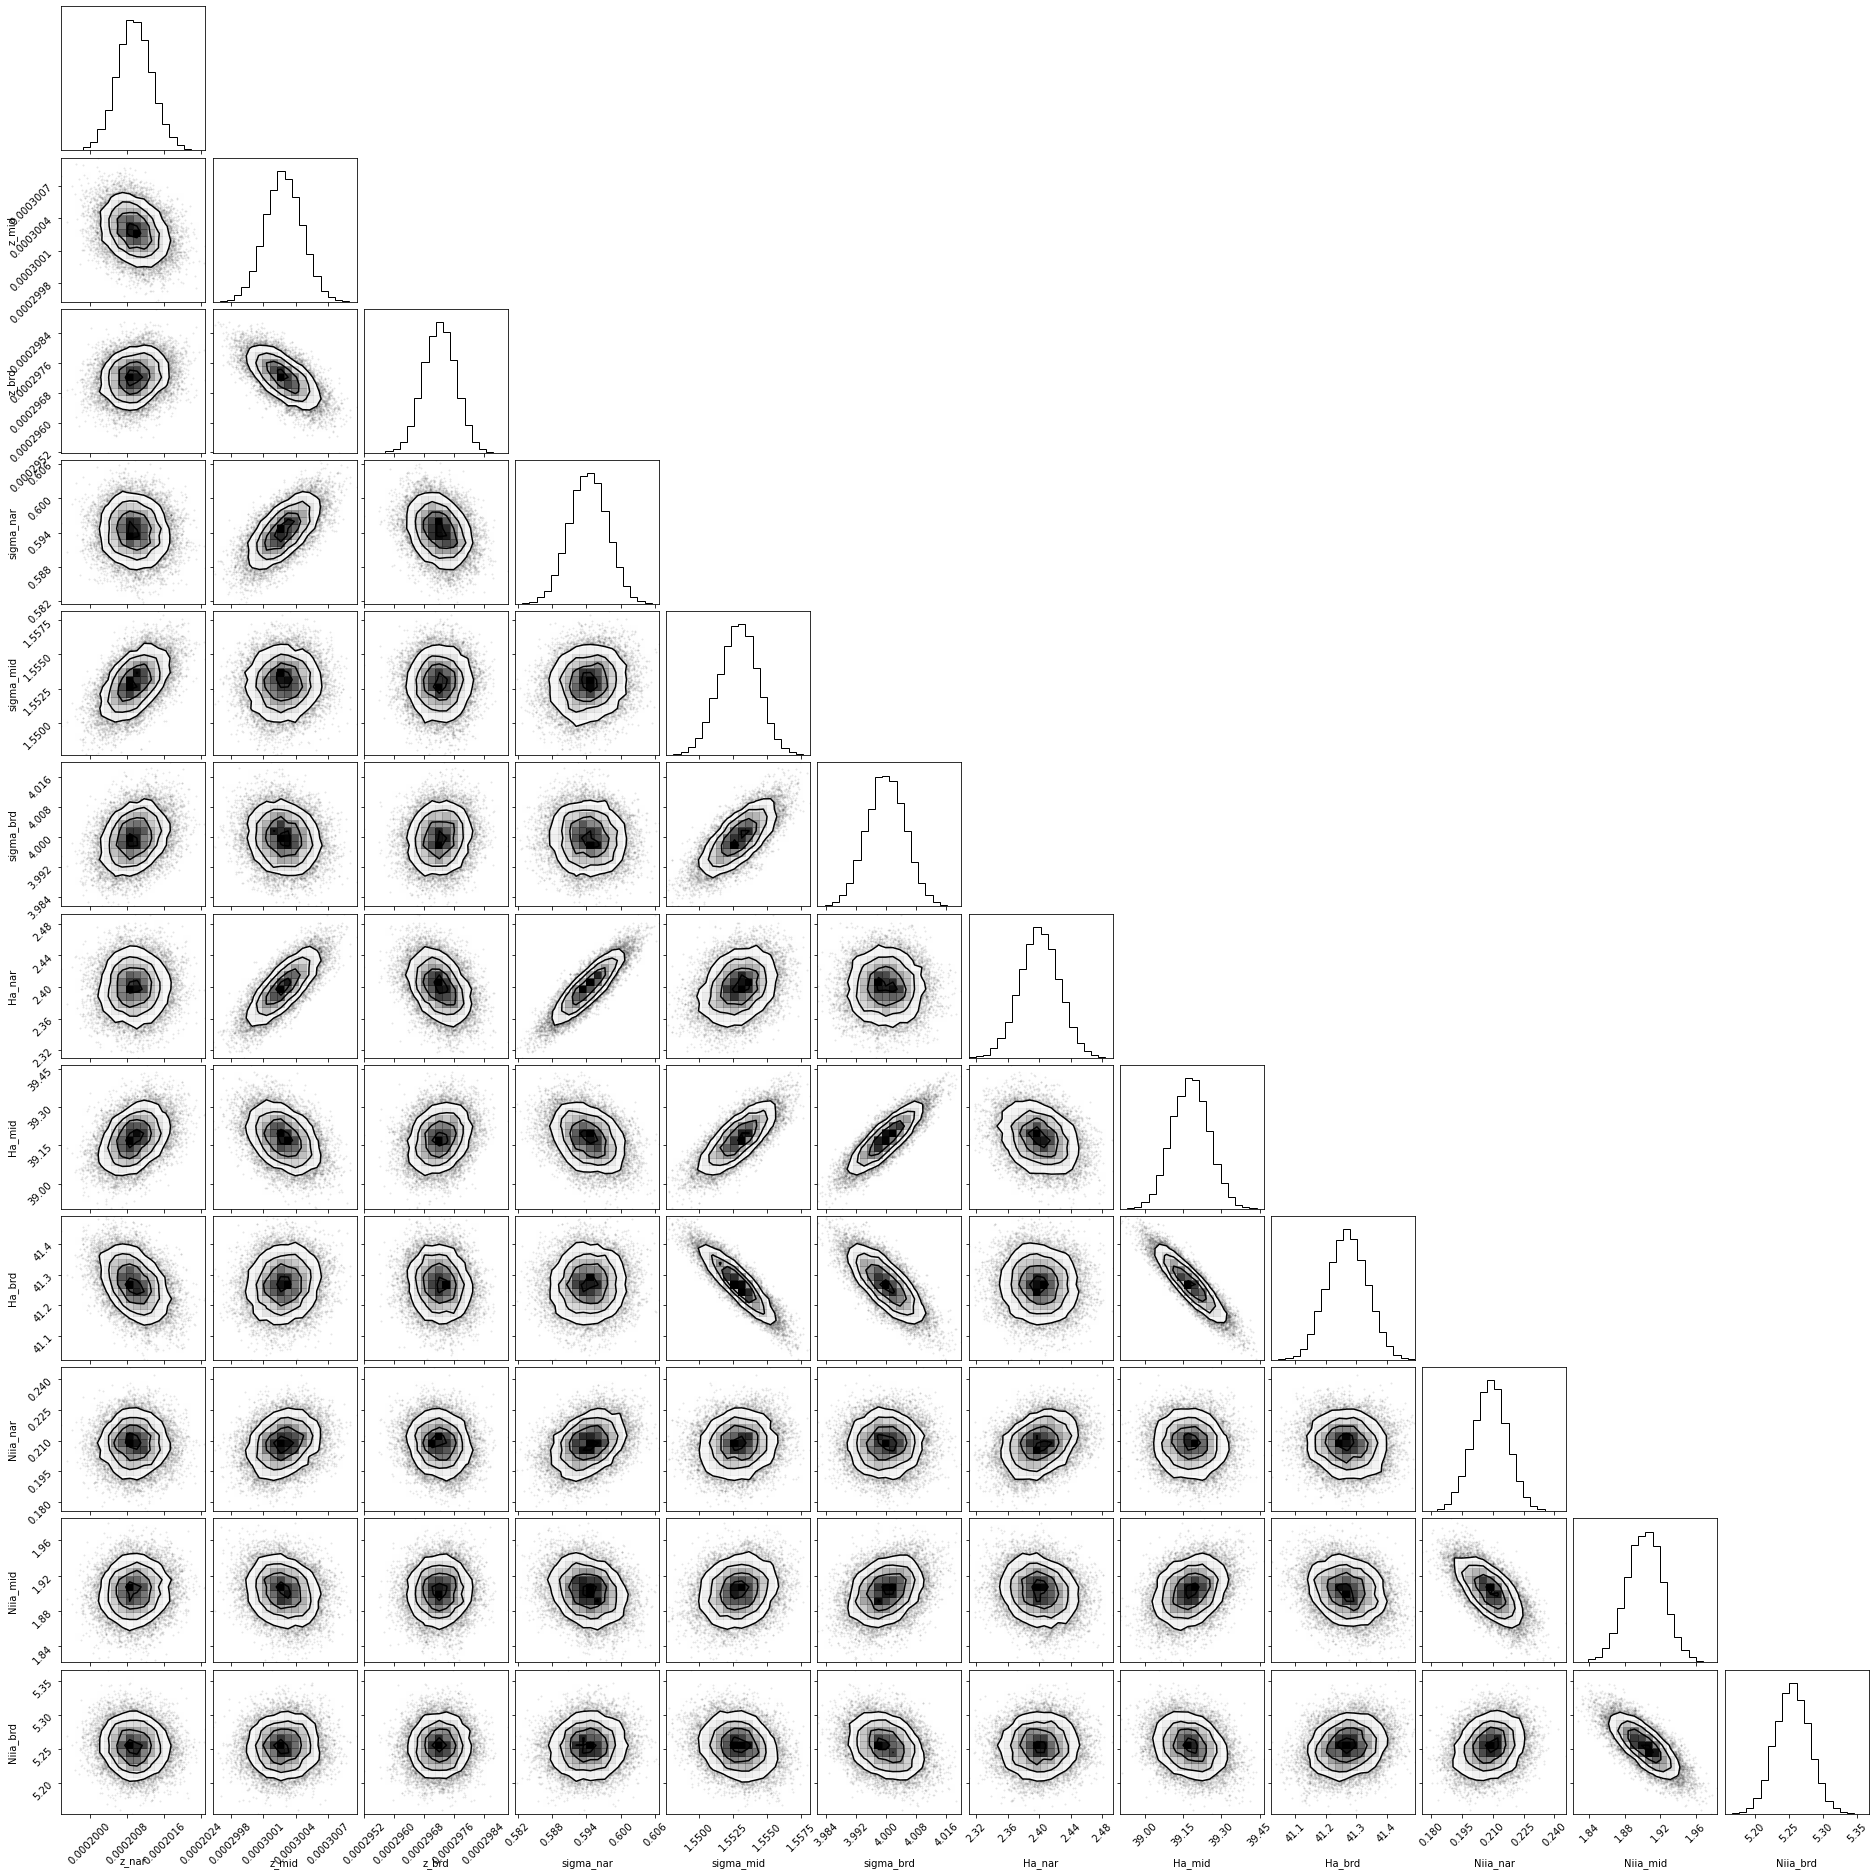

In [50]:
%matplotlib inline
corner.corner(out3_ha_nii.flatchain, labels=out3_ha_nii.var_names);

In [51]:
out3_ha_nii

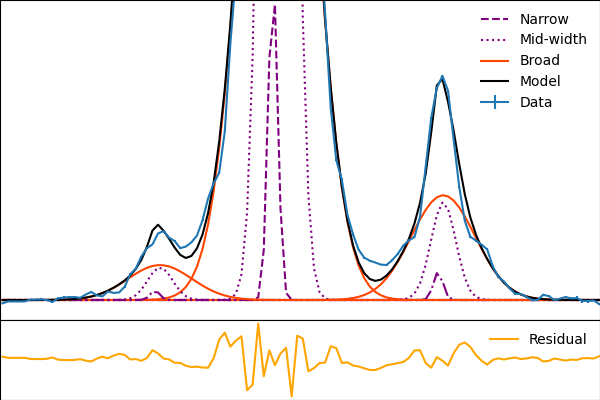

In [54]:
ha_nar = out3_ha_nii.flatchain.Ha_nar.mean()
ha_mid = out3_ha_nii.flatchain.Ha_mid.mean()
ha_brd = out3_ha_nii.flatchain.Ha_brd.mean()

niia_nar = out3_ha_nii.flatchain.Niia_nar.mean()
niia_mid = out3_ha_nii.flatchain.Niia_mid.mean()
niia_brd = out3_ha_nii.flatchain.Niia_brd.mean()

niib_nar = (out3_ha_nii.flatchain.Niia_nar/3).mean()
niib_mid = (out3_ha_nii.flatchain.Niia_mid/3).mean()
niib_brd = (out3_ha_nii.flatchain.Niia_brd/3).mean()

z_ha_nar = out3_ha_nii.flatchain.z_nar.mean()
z_ha_mid = out3_ha_nii.flatchain.z_mid.mean()
z_ha_brd = out3_ha_nii.flatchain.z_brd.mean()

sigma_ha_nar = out3_ha_nii.flatchain.sigma_nar.mean()
sigma_ha_mid = out3_ha_nii.flatchain.sigma_mid.mean()
sigma_ha_brd = out3_ha_nii.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='Data')


ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_mid = gaussian(wl_ha, niib_mid, niib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_mid = gaussian(wl_ha, ha_mid, ha_wav, z=z_ha_mid, sigma=sigma_ha_mid)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_mid = gaussian(wl_ha, niia_mid, niia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha = ha_nar + ha_mid + ha_brd
niia = niia_nar + niia_mid + niia_brd
niib = niib_nar + niib_mid + niib_brd

ax.plot(wl_ha, ha_nar, color='purple', ls='--', label='Narrow')
ax.plot(wl_ha, ha_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_ha, ha_brd, color='orangered', label='Broad')

ax.plot(wl_ha, niia_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia_mid, color='purple', ls=':')
ax.plot(wl_ha, niia_brd, color='orangered')

ax.plot(wl_ha, niib_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib_mid, color='purple', ls=':')
ax.plot(wl_ha, niib_brd, color='orangered')

ax.plot(wl_ha, niib + ha + niia, color='black', label='Model')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
ax.set_xlim(6530, 6605)
ax1.set_xlim(6530, 6605)
ax.set_ylim(-0.1, 1.5)
ax.set_xticks([])
#plt.savefig('3compfit_ha_zoom.png', bbox_inches='tight', facecolor='white')

## [OIII]$\lambda$5007

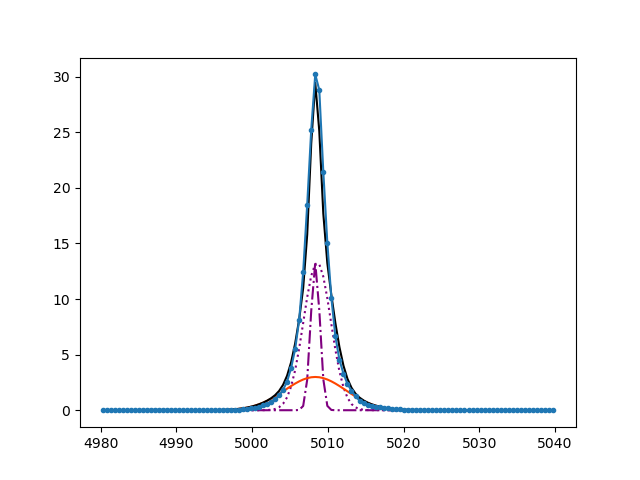

In [55]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_oiii5007, flux_oiii5007, noise_oiii5007,
             marker='o', markersize=3, label='data')

#air 
oiii5007_wav = 5006.843

# narrow and broad
oiii5007_nar = gaussian(wl_oiii5007, 20, oiii5007_wav, z=3.0e-04, sigma=0.6)
oiii5007_mid = gaussian(wl_oiii5007, 60, oiii5007_wav, z=3.5e-04, sigma=1.8)
oiii5007_brd = gaussian(wl_oiii5007, 30, oiii5007_wav, z=3.0e-04, sigma=4.0)

oiii5007 = oiii5007_nar + oiii5007_mid + oiii5007_brd

plt.plot(wl_oiii5007, oiii5007_nar, color='purple', ls='-.')
plt.plot(wl_oiii5007, oiii5007_mid, color='purple', ls=':')
plt.plot(wl_oiii5007, oiii5007_brd, color='orangered')

plt.plot(wl_oiii5007, oiii5007, color='black')

In [56]:
params3_oiii5007 = Parameters()

params3_oiii5007.add('z_nar', value=3.0e-04)
params3_oiii5007.add('z_mid', value=3.5e-04)
params3_oiii5007.add('z_brd', value=3.0e-04)

params3_oiii5007.add('sigma_nar', value=0.6, min=0.)
params3_oiii5007.add('sigma_mid', value=1.8, min=0.)
params3_oiii5007.add('sigma_brd', value=4.0, min=0.)

params3_oiii5007.add('Oiii5007_nar', value=20, min=0.)
params3_oiii5007.add('Oiii5007_mid', value=60, min=0.)
params3_oiii5007.add('Oiii5007_brd', value=30, min=0.)

def residual3_oiii5007(params3_oiii5007, x, data, uncertainty):
    oiii5007_wav = 5006.843
    
    z_nar = params3_oiii5007['z_nar']
    z_mid = params3_oiii5007['z_mid']
    z_brd = params3_oiii5007['z_brd']
    
    sigma_nar = params3_oiii5007['sigma_nar']
    sigma_mid = params3_oiii5007['sigma_mid']
    sigma_brd = params3_oiii5007['sigma_brd']
    
    oiii5007_nar = params3_oiii5007['Oiii5007_nar']
    oiii5007_mid = params3_oiii5007['Oiii5007_mid']
    oiii5007_brd = params3_oiii5007['Oiii5007_brd']
    
    x = wl_oiii5007
    
    model_oiii5007 = gaussian(x, oiii5007_nar, oiii5007_wav, z_nar, sigma_nar) \
                   + gaussian(x, oiii5007_mid, oiii5007_wav, z_mid, sigma_mid) \
                   + gaussian(x, oiii5007_brd, oiii5007_wav, z_brd, sigma_brd)
    
    return (model_oiii5007 - flux_oiii5007) / noise_oiii5007

In [57]:
n_params3_oiii5007 = 9
out3_oiii5007 = minimize(residual3_oiii5007, params3_oiii5007, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, nwalkers=n_params3_oiii5007*9, seed=1)

100%|██████████████████████████████████████| 3000/3000 [00:23<00:00, 128.33it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 9 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [245.61917974 212.82439273 247.94981001 253.57755305 286.68699911
 278.58398109 332.18025315 197.83012936 319.05933281]


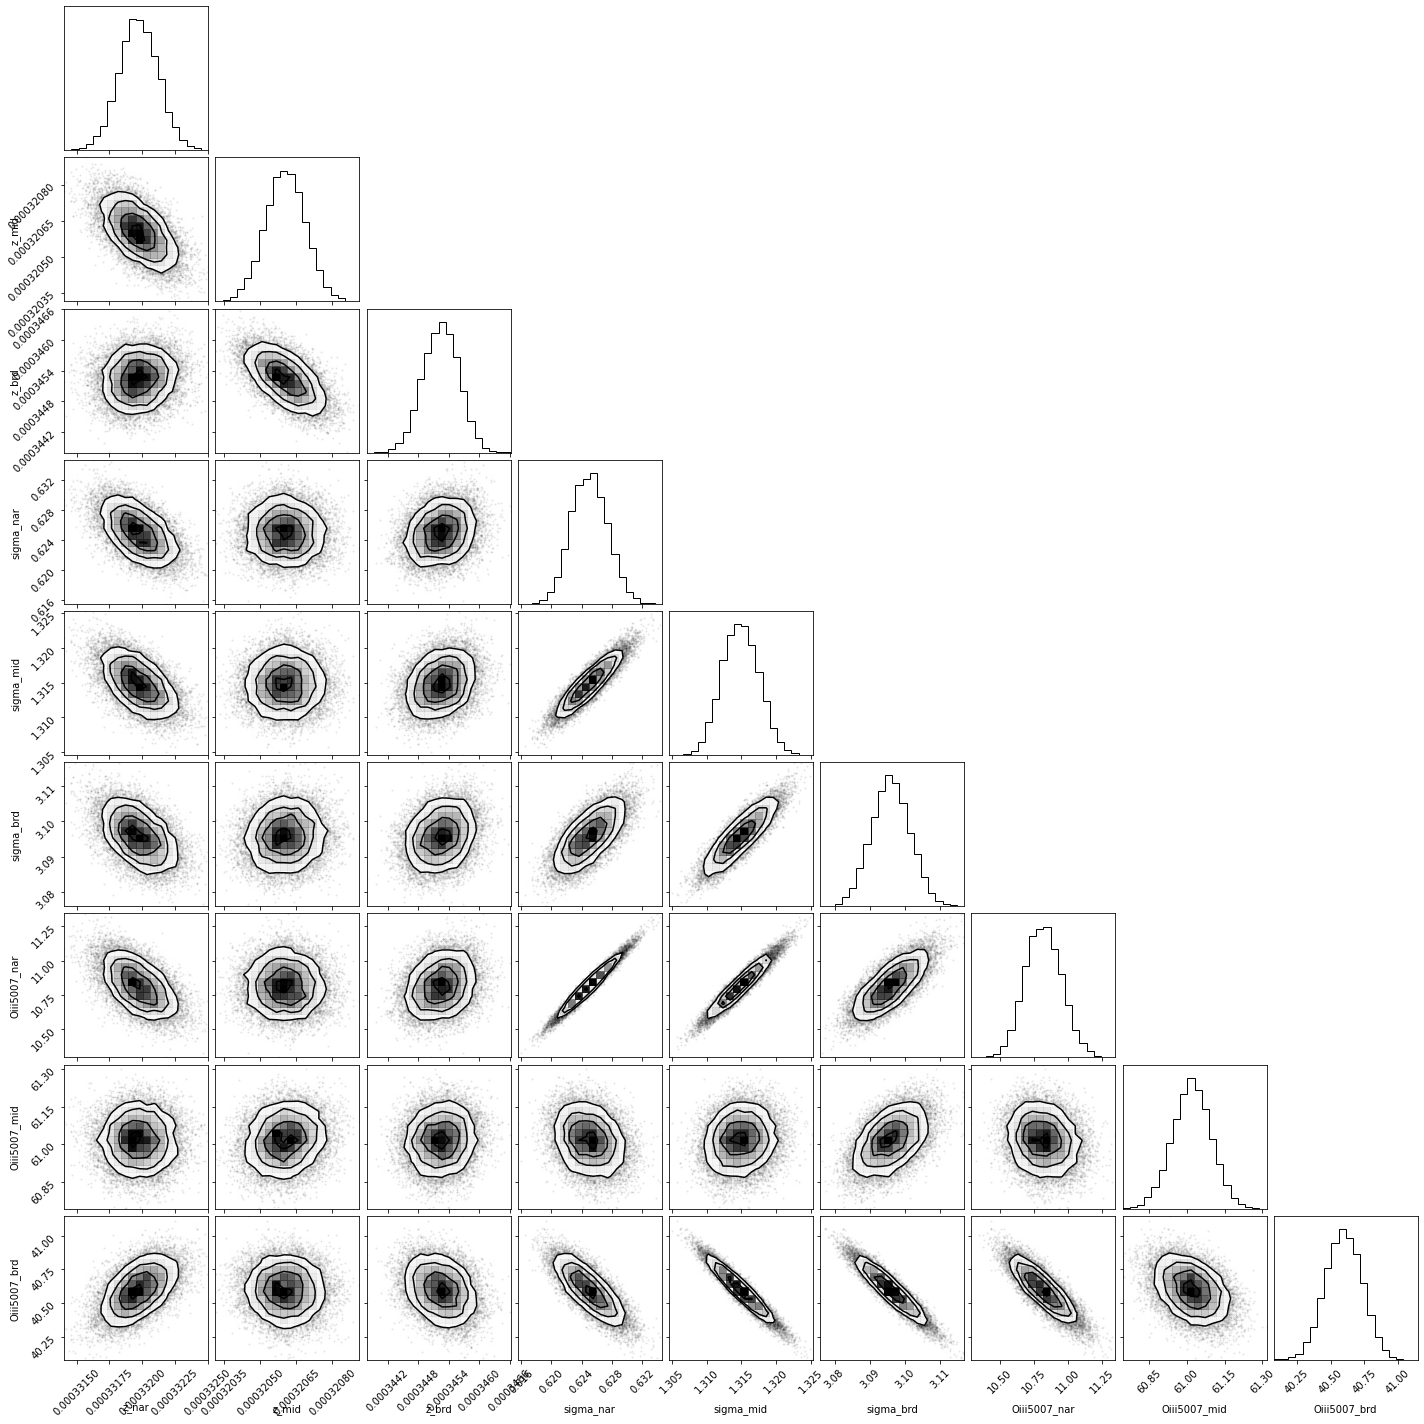

In [58]:
%matplotlib inline
corner.corner(out3_oiii5007.flatchain, labels=out3_oiii5007.var_names);

In [59]:
out3_oiii5007

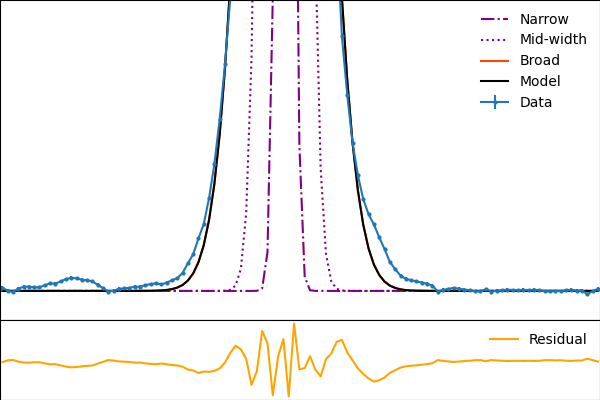

In [63]:
oiii5007_nar = out3_oiii5007.flatchain.Oiii5007_nar.mean()
oiii5007_mid = out3_oiii5007.flatchain.Oiii5007_mid.mean()
oiii5007_brd = out3_oiii5007.flatchain.Oiii5007_brd.mean()

z_oiii5007_nar = out3_oiii5007.flatchain.z_nar.mean()
z_oiii5007_mid = out3_oiii5007.flatchain.z_mid.mean()
z_oiii5007_brd = out3_oiii5007.flatchain.z_brd.mean()

sigma_oiii5007_nar = out3_oiii5007.flatchain.sigma_nar.mean()
sigma_oiii5007_mid = out3_oiii5007.flatchain.sigma_mid.mean()
sigma_oiii5007_brd = out3_oiii5007.flatchain.sigma_brd.mean()

# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

#data
ax.errorbar(wl_oiii5007, flux_oiii5007, noise_oiii5007, marker='.', markersize=4, label='Data')

oiii5007_nar = gaussian(wl_oiii5007, oiii5007_nar, oiii5007_wav, z=z_oiii5007_nar, sigma=sigma_oiii5007_nar)
oiii5007_mid = gaussian(wl_oiii5007, oiii5007_mid, oiii5007_wav, z=z_oiii5007_mid, sigma=sigma_oiii5007_mid)
oiii5007_brd = gaussian(wl_oiii5007, oiii5007_brd, oiii5007_wav, z=z_oiii5007_brd, sigma=sigma_oiii5007_brd)

oiii5007 = oiii5007_nar + oiii5007_mid + oiii5007_brd

ax.plot(wl_oiii5007, oiii5007_nar, color='purple', ls='-.', label='Narrow')
ax.plot(wl_oiii5007, oiii5007_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_oiii5007, oiii5007_brd, color='orangered', label='Broad')
ax.plot(wl_oiii5007, oiii5007, color='black', label='Model')
                   
ax1.plot(wl_oiii5007, oiii5007 - flux_oiii5007, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
ax.set_xticks([])
ax.set_xlim(4980, 5040)
ax1.set_xlim(4980, 5040)
ax.set_ylim(-0.1, 1.0)
#plt.savefig('3compfit_oiii_zoom.png', bbox_inches='tight', facecolor='white')

In [64]:
nu3_ha_nii = len(flux_ha) - n_params3_ha_nii
print('ReducedXi2 for 3 gaussians for Ha '\
      + str(np.sum((niib + ha + niia - flux_ha)**2 / noise_ha) / nu3_ha_nii))

ReducedXi2 for 3 gaussians for Ha 1.6291891246262018


In [65]:
nu3_oiii5007 = len(flux_oiii5007) - n_params3_oiii5007
print('Reduced Xi2 for 3 gaussians for OIII '\
      + str(np.sum((oiii5007 - flux_oiii5007)**2 / noise_oiii5007) / nu3_oiii5007))

Reduced Xi2 for 3 gaussians for OIII 0.9585634300547029


# 4 gaussians ?

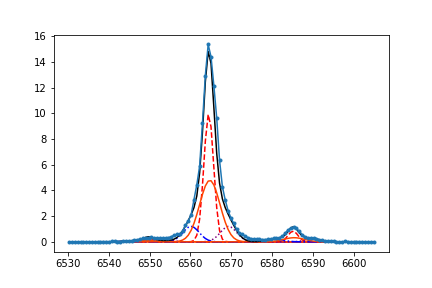

In [177]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 30, ha_wav, z=2.6e-04, sigma=1.2)
ha_mid = gaussian(wl_ha, 6, ha_wav, z=10.0e-04, sigma=2.0)
ha_out = gaussian(wl_ha, 6, ha_wav, z=-4e-04, sigma=2.0)
ha_brd = gaussian(wl_ha, 30, ha_wav, z=3e-04, sigma=2.5)

niib_nar = gaussian(wl_ha, 2.5/3, niib_wav, z=2.6e-04, sigma=1.2)
niib_mid = gaussian(wl_ha,   1/3, niib_wav, z=10.0e-04, sigma=2.0)
niib_out = gaussian(wl_ha,   1/3, niib_wav, z=-4e-04, sigma=2.0)
niib_brd = gaussian(wl_ha,   2/3, niib_wav, z=3e-04, sigma=2.5)

niia_nar = gaussian(wl_ha, 2.5, niia_wav, z=2.6e-04, sigma=1.2)
niia_mid = gaussian(wl_ha,   1, niia_wav, z=10.0e-04, sigma=2.0)
niia_out = gaussian(wl_ha,   1, niia_wav, z=-4e-04, sigma=2.0)
niia_brd = gaussian(wl_ha,   2, niia_wav, z=3e-04, sigma=2.5)

# total
ha = ha_nar + ha_mid + ha_out + ha_brd
niib = niib_nar + niib_mid + niib_out + niib_brd
niia = niia_nar + niia_mid + niia_out + niia_brd

plt.plot(wl_ha, ha_nar, color='red', ls='--')
plt.plot(wl_ha, ha_mid, color='purple', ls=':')
plt.plot(wl_ha, ha_out, color='blue', ls='-.')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='red', ls='--')
plt.plot(wl_ha, niib_mid, color='purple', ls=':')
plt.plot(wl_ha, niib_out, color='blue', ls='-.')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='red', ls='--')
plt.plot(wl_ha, niia_mid, color='purple', ls=':')
plt.plot(wl_ha, niia_out, color='blue', ls='-.')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [179]:
params4_ha_nii = Parameters()

params4_ha_nii.add('z_nar', value=2.6e-04)
params4_ha_nii.add('z_mid', value=10.0e-04)
params4_ha_nii.add('z_out', value=-4e-04)
params4_ha_nii.add('z_brd', value=3e-04)

params4_ha_nii.add('sigma_nar', value=1.2, min=0.)
params4_ha_nii.add('sigma_mid', value=2.0, min=0.)
params4_ha_nii.add('sigma_out', value=2.0, min=0.)
params4_ha_nii.add('sigma_brd', value=2.5, min=0.)

params4_ha_nii.add('Ha_nar', value=30, min=0.)
params4_ha_nii.add('Ha_mid', value=6, min=0.)
params4_ha_nii.add('Ha_out', value=6, min=0.)
params4_ha_nii.add('Ha_brd', value=30, min=0.)

params4_ha_nii.add('Niia_nar', value=2.5, min=0.)
params4_ha_nii.add('Niia_mid', value=1, min=0.)
params4_ha_nii.add('Niia_out', value=1, min=0.)
params4_ha_nii.add('Niia_brd', value=2, min=0.)

params4_ha_nii.add('Niib_to_niia', value=1/3, vary=False)


def residual4_ha_nii(params4_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params4_ha_nii['z_nar']
    z_mid = params4_ha_nii['z_mid']
    z_out = params4_ha_nii['z_out']
    z_brd = params4_ha_nii['z_brd']
    
    sigma_nar = params4_ha_nii['sigma_nar']
    sigma_mid = params4_ha_nii['sigma_mid']
    sigma_out = params4_ha_nii['sigma_out']
    sigma_brd = params4_ha_nii['sigma_brd']
    
    ha_nar = params4_ha_nii['Ha_nar']
    ha_mid = params4_ha_nii['Ha_mid']
    ha_out = params4_ha_nii['Ha_out']
    ha_brd = params4_ha_nii['Ha_brd']
    
    niia_nar = params4_ha_nii['Niia_nar']
    niia_mid = params4_ha_nii['Niia_mid']
    niia_out = params4_ha_nii['Niia_out']
    niia_brd = params4_ha_nii['Niia_brd']
    
    niib_nar = params4_ha_nii['Niia_nar']*params4_ha_nii['Niib_to_niia']
    niib_mid = params4_ha_nii['Niia_mid']*params4_ha_nii['Niib_to_niia']
    niib_out = params4_ha_nii['Niia_out']*params4_ha_nii['Niib_to_niia']
    niib_brd = params4_ha_nii['Niia_brd']*params4_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_mid, ha_wav, z_mid, sigma_mid) \
             + gaussian(x, ha_out, ha_wav, z_out, sigma_out) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_mid, niia_wav, z_mid, sigma_mid) \
               + gaussian(x, niia_out, niia_wav, z_out, sigma_out) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd) \
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_mid, niib_wav, z_mid, sigma_mid) \
               + gaussian(x, niib_out, niib_wav, z_out, sigma_out) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd) \
    
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [180]:
n_params4_ha_nii = 16
out4_ha_nii = minimize(residual4_ha_nii, params4_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, nwalkers=n_params4_ha_nii*9, seed=1)

100%|███████████████████████████████████████| 3000/3000 [01:46<00:00, 28.21it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 16 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [402.03810268 168.24071144 400.72119098 266.02652163 404.49603055
 172.34085076 354.1623974  388.08248016 408.84552274 173.74601152
 409.10435761 303.94611279 409.59161976 132.63332783 403.13321766
 375.53490523]


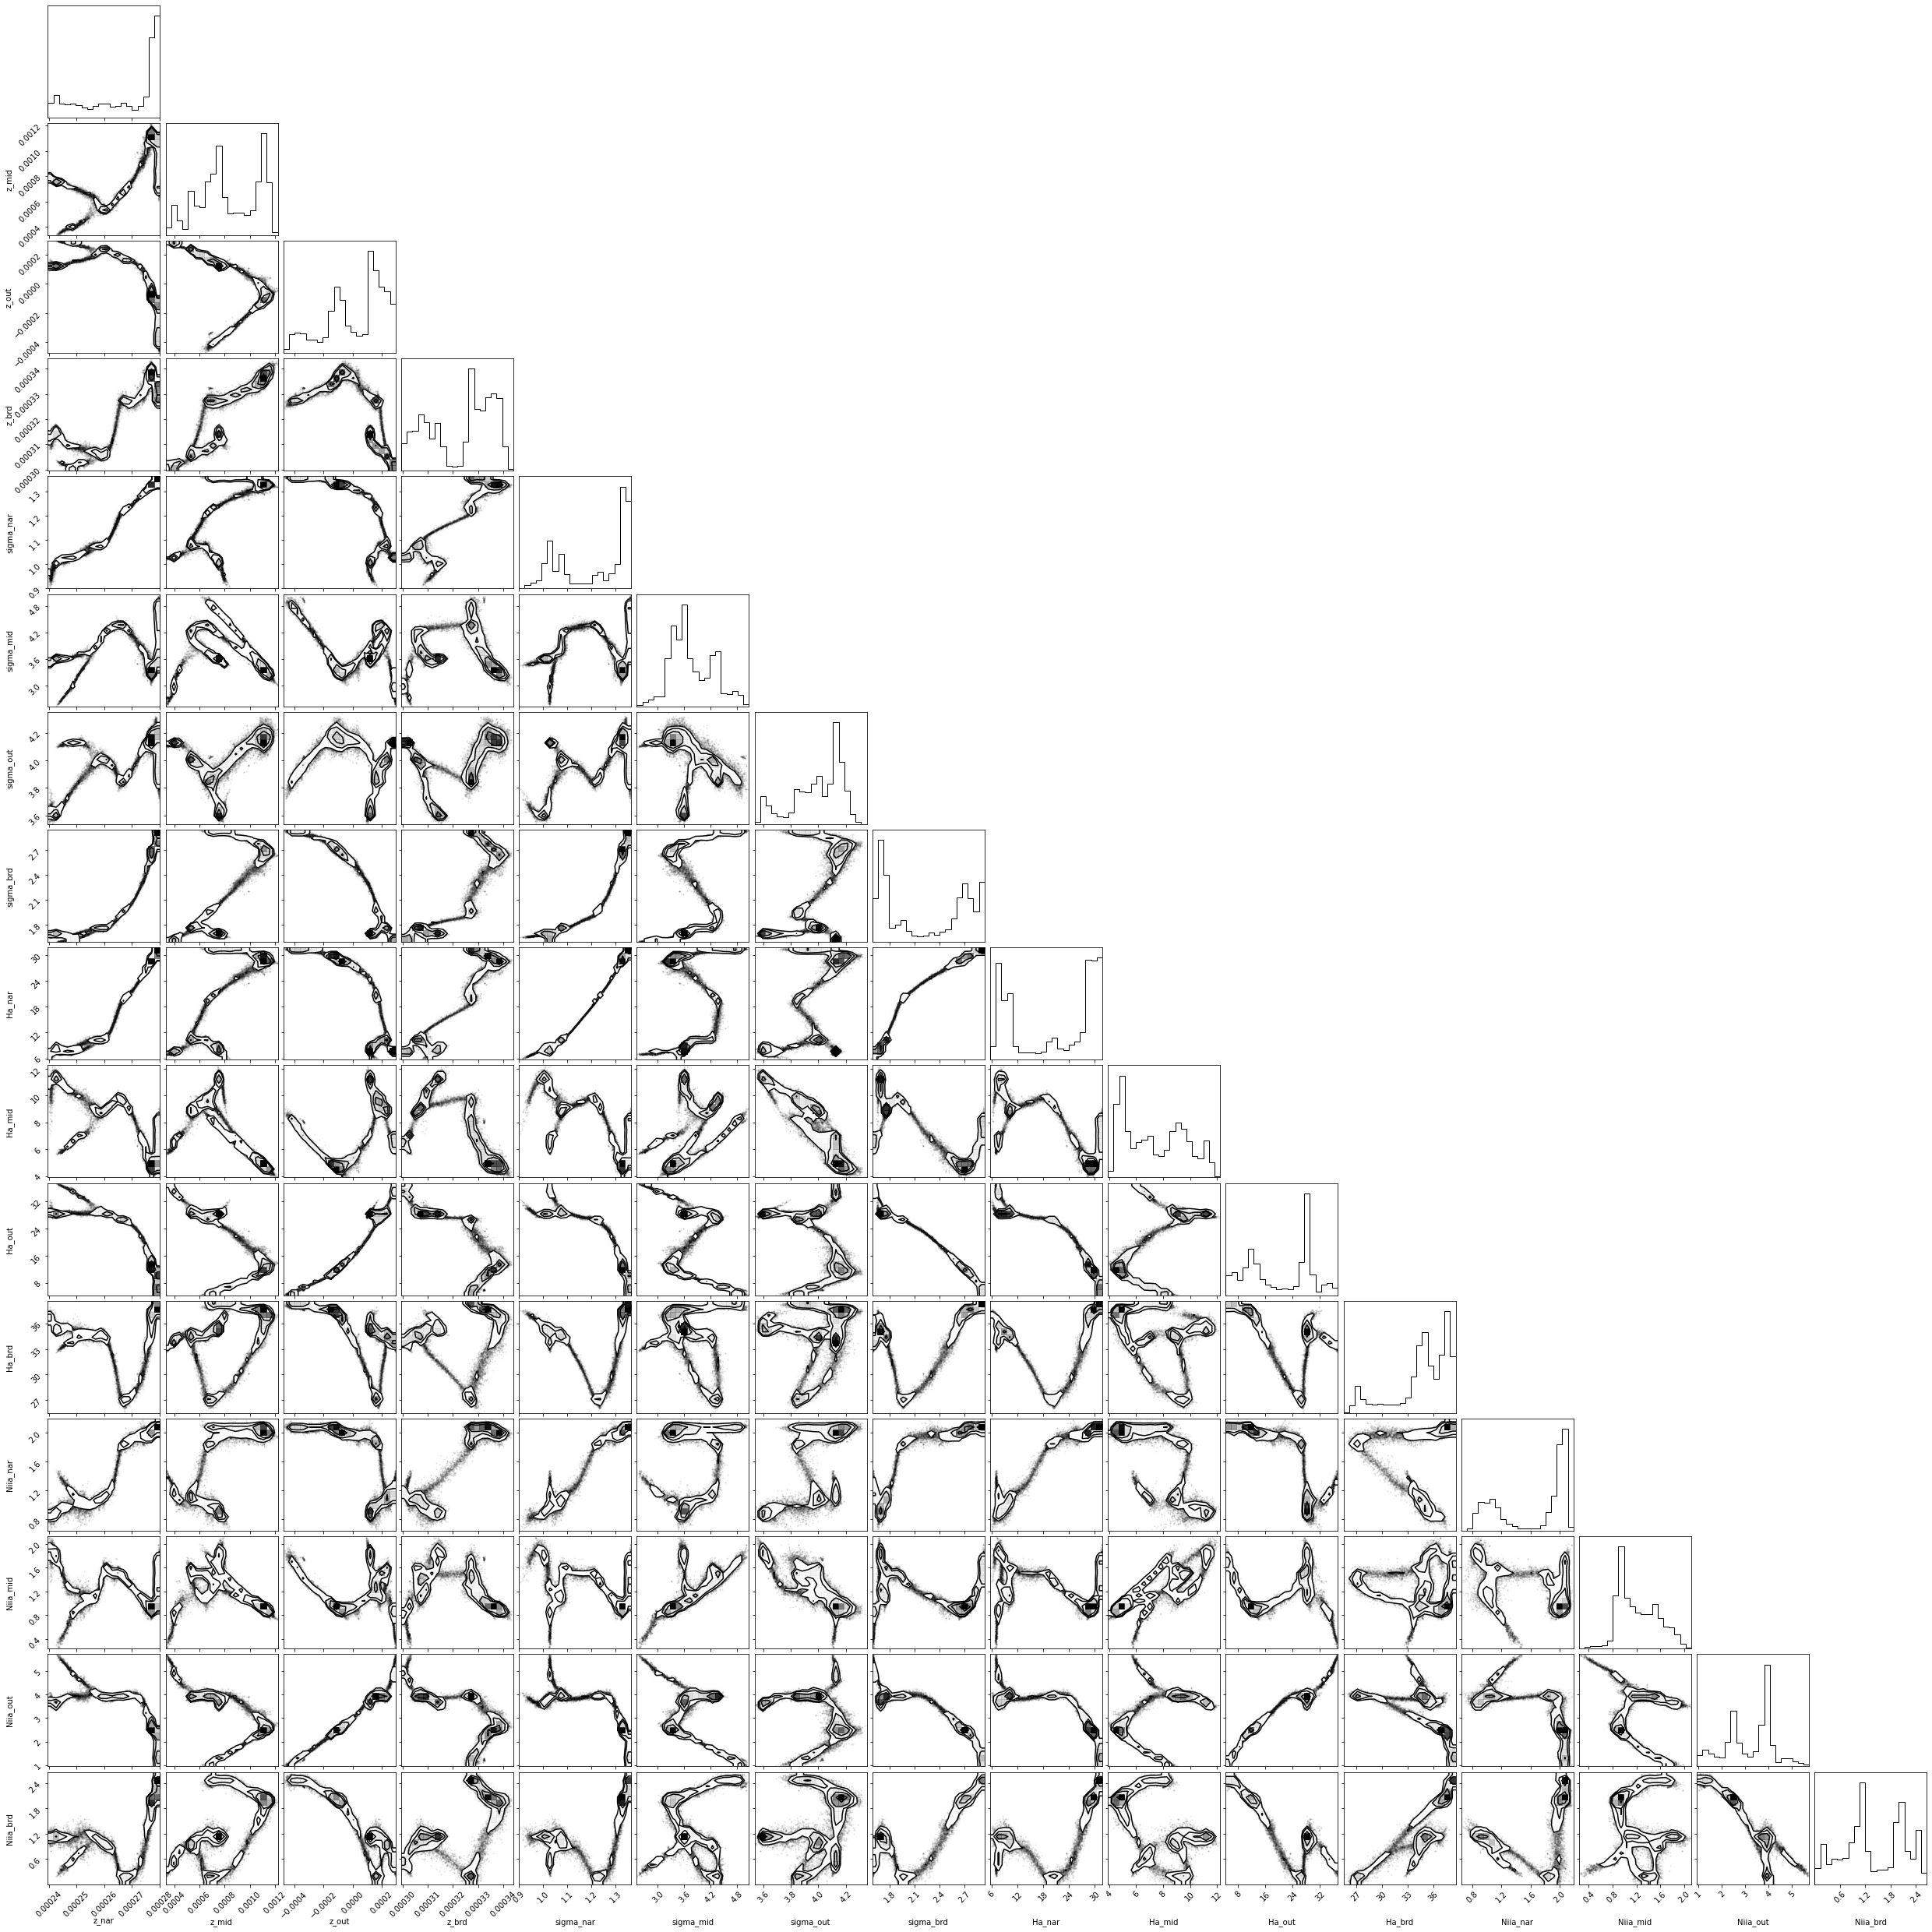

In [181]:
%matplotlib inline
corner.corner(out4_ha_nii.flatchain, labels=out4_ha_nii.var_names);

In [183]:
out4_ha_nii

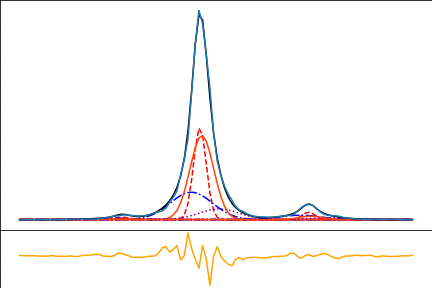

In [182]:
ha_nar = out4_ha_nii.flatchain.Ha_nar.mean()
ha_mid = out4_ha_nii.flatchain.Ha_mid.mean()
ha_out = out4_ha_nii.flatchain.Ha_out.mean()
ha_brd = out4_ha_nii.flatchain.Ha_brd.mean()

niia_nar = out4_ha_nii.flatchain.Niia_nar.mean()
niia_mid = out4_ha_nii.flatchain.Niia_mid.mean()
niia_out = out4_ha_nii.flatchain.Niia_out.mean()
niia_brd = out4_ha_nii.flatchain.Niia_brd.mean()

niib_nar = out4_ha_nii.flatchain.Niia_nar.mean()/3
niib_mid = out4_ha_nii.flatchain.Niia_mid.mean()/3
niib_out = out4_ha_nii.flatchain.Niia_out.mean()/3
niib_brd = out4_ha_nii.flatchain.Niia_brd.mean()/3

z_ha_nar = out4_ha_nii.flatchain.z_nar.mean()
z_ha_mid = out4_ha_nii.flatchain.z_mid.mean()
z_ha_out = out4_ha_nii.flatchain.z_out.mean()
z_ha_brd = out4_ha_nii.flatchain.z_brd.mean()

sigma_ha_nar = out4_ha_nii.flatchain.sigma_nar.mean()
sigma_ha_mid = out4_ha_nii.flatchain.sigma_mid.mean()
sigma_ha_out = out4_ha_nii.flatchain.sigma_out.mean()
sigma_ha_brd = out4_ha_nii.flatchain.sigma_brd.mean()


# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='data')


ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_mid = gaussian(wl_ha, niib_mid, niib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niib_out = gaussian(wl_ha, niib_out, niib_wav, z=z_ha_out, sigma=sigma_ha_out)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_mid = gaussian(wl_ha, ha_mid, ha_wav, z=z_ha_mid, sigma=sigma_ha_mid)
ha_out = gaussian(wl_ha, ha_out, ha_wav, z=z_ha_out, sigma=sigma_ha_out)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_mid = gaussian(wl_ha, niia_mid, niia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niia_out = gaussian(wl_ha, niia_out, niia_wav, z=z_ha_out, sigma=sigma_ha_out)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
ha = ha_nar + ha_mid + ha_out + ha_brd
niib = niib_nar + niib_mid + niib_out + niib_brd
niia = niia_nar + niia_mid + niia_out + niia_brd

ax.plot(wl_ha, ha_nar, color='red', ls='--')
ax.plot(wl_ha, ha_mid, color='purple', ls=':')
ax.plot(wl_ha, ha_out, color='blue', ls='-.')
ax.plot(wl_ha, ha_brd, color='orangered')

ax.plot(wl_ha, niib_nar, color='red', ls='--')
ax.plot(wl_ha, niib_mid, color='purple', ls=':')
ax.plot(wl_ha, niib_out, color='blue', ls='-.')
ax.plot(wl_ha, niib_brd, color='orangered')

ax.plot(wl_ha, niia_nar, color='red', ls='--')
ax.plot(wl_ha, niia_mid, color='purple', ls=':')
ax.plot(wl_ha, niia_out, color='blue', ls='-.')
ax.plot(wl_ha, niia_brd, color='orangered')

ax.plot(wl_ha, niib + ha + niia, color='black')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange')

In [184]:
nu4_ha_nii = len(flux_ha) - n_params4_ha_nii
print('Reduced Xi2 for 4 gaussians for Ha '\
      + str(np.sum((niib + ha + niia - flux_ha)**2 / noise_ha) / nu4_ha_nii))

Reduced Xi2 for 4 gaussians for Ha 3.7760932425558735
